## Correlation analysis

In [1]:
import pandas as pd
from glob import glob
import numpy as np
from scipy.stats import spearmanr, pearsonr
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
from collections import defaultdict
plt.style.use("seaborn-v0_8-whitegrid")
pd.options.display.float_format = '{:.2f}'.format

In [2]:
def load_score_data(path): 
    files = glob(path)
    data = []
    for file in files:
        # print(file)
        temp = pd.read_csv(file)
        data.append(temp)
    data = pd.concat(data, axis=0)
    data = data.rename(columns={"Unnamed: 0": "name"})
    
    return data
    
def get_avg_human_ratings(filename_human):
    df = pd.read_csv(filename_human)
    avg = df.groupby(["condition", 
                      "stimuli_type", 
                      "name"])["natural_rating"].describe()[["mean", "std"]].reset_index()
    
    return avg

def get_avg_model_ratings(filename, model, open_source=True):
    df = []
    for file in glob(filename):
        temp = pd.read_csv(file)
        df.append(temp)
    df = pd.concat(df, axis=0)
    if open_source:
        df["condition"] = df["condition"].str.replace("r", "relevant")
        df["condition"] = df["condition"].str.replace("i", "irrelevant")
        
    df["stimuli_type"] = np.where(df["name"].str.startswith("or"), "original", "backtranslated")
    avg = df.groupby(["condition", 
                      "stimuli_type", 
                      "name"])["natural"].describe()[["mean", "std"]].reset_index()
    avg["model"] = model
    
    return avg
    
def get_avg_model_scores(data, metric):
    if metric == "logprob":
        
        r = data[["name", "r_logprob", "model"]]
        r = r.groupby(["model", "name"])["r_logprob"].mean().reset_index()
        r = r.rename(columns = {"r_logprob": "relevant"})

        i = data[["name", "i_logprob", "model"]]
        i = i.groupby(["model", "name"])["i_logprob"].mean().reset_index()
        i = i.rename(columns = {"i_logprob": "irrelevant"})
    
        n = data[["name", "n_logprob", "model"]]
        n = n.groupby(["model", "name"])["n_logprob"].mean().reset_index()
        n = n.rename(columns = {"n_logprob": "n"})
    
        df = pd.concat([r, i["irrelevant"], n["n"]], axis=1)

    elif metric == "logprob_norm":
        
        r = data[["name", "r_logprob_norm", "model"]]
        r = r.groupby(["model", "name"])["r_logprob_norm"].mean().reset_index()
        r = r.rename(columns = {"r_logprob_norm": "relevant"})
        
        i = data[["name", "i_logprob_norm", "model"]]
        i = i.groupby(["model", "name"])["i_logprob_norm"].mean().reset_index()
        i = i.rename(columns = {"i_logprob_norm": "irrelevant"})
    
        n = data[["name", "n_logprob_norm", "model"]]
        n = n.groupby(["model", "name"])["n_logprob_norm"].mean().reset_index()
        n = n.rename(columns = {"n_logprob_norm": "n"})
        
        df = pd.concat([r, i["irrelevant"], n["n"]], axis=1)

    elif metric == "perplexity":
        
        r = data[["name", "r_perp", "model"]]
        r = r.groupby(["model", "name"])["r_perp"].mean().reset_index()
        r = r.rename(columns = {"r_perp": "relevant"})
        
        i = data[["name", "i_perp", "model"]]
        i = i.groupby(["model", "name"])["i_perp"].mean().reset_index()
        i = i.rename(columns = {"i_perp": "irrelevant"})
    
        n = data[["name", "n_perp", "model"]]
        n = n.groupby(["model", "name"])["n_perp"].mean().reset_index()
        n = n.rename(columns = {"n_perp": "n"})
        
        df = pd.concat([r, i["irrelevant"], n["n"]], axis=1)


    elif metric == "penlp":
        
        r = data[["name", "r_penlp", "model"]]
        r = r.groupby(["model", "name"])["r_penlp"].mean().reset_index()
        r = r.rename(columns = {"r_penlp": "relevant"})

        i = data[["name", "i_penlp", "model"]]
        i = i.groupby(["model", "name"])["i_penlp"].mean().reset_index()
        i = i.rename(columns = {"i_penlp": "irrelevant"})
    
        n = data[["name", "n_penlp", "model"]]
        n = n.groupby(["model", "name"])["n_penlp"].mean().reset_index()
        n = n.rename(columns = {"n_penlp": "n"})
    
        df = pd.concat([r, i["irrelevant"], n["n"]], axis=1)
        
    df = pd.melt(df, 
        id_vars=["model", "name"], 
        value_vars=["relevant", "irrelevant", "n"], 
        var_name="condition",
        value_name="mean")

    df["stimuli_type"] = np.where(df["name"].str.startswith("or"), "original", "backtranslated")
    df = df.groupby(["condition", "stimuli_type", "name", "model"])["mean"].mean().reset_index()

    return df


def calc_corr(df1, df2, model, method="spearman"):

    df1 = df1[df1["model"] == model]
    
    # original vs backtranslated
    o1 = df1[df1["stimuli_type"] == "original"]
    o2 = df2[df2["stimuli_type"] == "original"]

    b1 = df1[df1["stimuli_type"] == "backtranslated"]
    b2 = df2[df2["stimuli_type"] == "backtranslated"]

    # sanity check
    assert o1[["condition", 
               "stimuli_type",  
               "name"]].all().all() == o2[["condition", 
                                           "stimuli_type", 
                                           "name"]].all().all()
    assert b1[["condition", 
               "stimuli_type", 
               "name"]].all().all() == b2[["condition", 
                                           "stimuli_type", 
                                           "name"]].all().all()
    
    # conditions
    r1 = df1[df1["condition"] == "relevant"]
    r2 = df2[df2["condition"] == "relevant"]

    i1 = df1[df1["condition"] == "irrelevant"]
    i2 = df2[df2["condition"] == "irrelevant"]

    n1 = df1[df1["condition"] == "n"]
    n2 = df2[df2["condition"] == "n"]
    
    # sanity check
    assert r1[["condition", 
               "stimuli_type", 
               "name"]].all().all() == r2[["condition", 
                                           "stimuli_type", 
                                           "name"]].all().all()
    assert i1[["condition", 
               "stimuli_type", 
               "name"]].all().all() == i2[["condition", 
                                           "stimuli_type", 
                                           "name"]].all().all()
    assert n1[["condition", 
               "stimuli_type", 
               "name"]].all().all() == n2[["condition", 
                                           "stimuli_type", 
                                           "name"]].all().all()

    corrs = defaultdict(list)
    if method == "spearman":

        #all
        results = spearmanr(df1["mean"], df2["mean"])
        rho = round(results.statistic, 2)
        pval = round(results.pvalue, 3)
        corrs["rho"].append(rho)
        corrs["pval"].append(pval)

        #null
        results = spearmanr(n1["mean"], n2["mean"])
        rho = round(results.statistic, 2)
        pval = round(results.pvalue, 3)
        corrs["rho"].append(rho)
        corrs["pval"].append(pval)
        
        #relevant
        results = spearmanr(r1["mean"], r2["mean"])
        rho = round(results.statistic, 2)
        pval = round(results.pvalue, 3)
        corrs["rho"].append(rho)
        corrs["pval"].append(pval)

        #irrelevant
        results = spearmanr(i1["mean"], i2["mean"])
        rho = round(results.statistic, 2)
        pval = round(results.pvalue, 3)
        corrs["rho"].append(rho)
        corrs["pval"].append(pval)

        corrs = pd.DataFrame.from_dict(corrs, orient="index", 
                                       columns=["all", "null", "relevant", "irrelevant"])
        corrs["model"] = model
        corrs["correlation"] = method
        
    elif method == "pearson":

        #all
        results = pearsonr(df1["mean"], df2["mean"])
        rho = round(results.statistic, 2)
        pval = round(results.pvalue, 3)
        corrs["r"].append(rho)
        corrs["pval"].append(pval)

        #null
        results = pearsonr(n1["mean"], n2["mean"])
        rho = round(results.statistic, 2)
        pval = round(results.pvalue, 3)
        corrs["r"].append(rho)
        corrs["pval"].append(pval)
        
        #relevant
        results = pearsonr(r1["mean"], r2["mean"])
        rho = round(results.statistic, 2)
        pval = round(results.pvalue, 3)
        corrs["r"].append(rho)
        corrs["pval"].append(pval)

        #irrelevant
        results = pearsonr(i1["mean"], i2["mean"])
        rho = round(results.statistic, 2)
        pval = round(results.pvalue, 3)
        corrs["r"].append(rho)
        corrs["pval"].append(pval)

        corrs = pd.DataFrame.from_dict(corrs, orient="index", 
                                       columns=["all", "null", "relevant", "irrelevant"])
        corrs["model"] = model
        corrs["correlation"] = method

    return corrs
        

def plot_data(df1, df2, model, x_name, y_name):
    """df1 = model data, df2 = human data"""
    
    df1 = df1[df1["model"] == model]

    # conditions
    r1 = df1[df1["condition"] == "relevant"]
    r2 = df2[df2["condition"] == "relevant"]

    i1 = df1[df1["condition"] == "irrelevant"]
    i2 = df2[df2["condition"] == "irrelevant"]

    n1 = df1[df1["condition"] == "n"]
    n2 = df2[df2["condition"] == "n"]

    # three plots
    fig, (ax, ax1, ax2) = plt.subplots(1, 3, figsize=(24, 6))
    fig.subplots_adjust(left=0.05)    
    c="m" # color
    fs_big = 24
    fs_small = 20
    
    #----------------------first plot-----------------------------
    x = n1["mean"].array
    y = n2["mean"].array
    #------------------------------------------------------------
    
    ax.scatter(x, y, c=c, edgecolors= None, label="Sentence", alpha=0.3)
    ax.set_xlabel(x_name, fontsize=fs_big)
    ax.set_ylabel(y_name, fontsize=fs_big, rotation=0)
    ax.legend(fontsize=fs_small)
    ax.set_yticks([1,2,3,4])
    ax.grid(False)
    ax.set_title("(a) Null", fontsize=fs_big)

    #----------------------second plot-----------------------------
    x = r1["mean"].array
    y = r2["mean"].array
    #------------------------------------------------------------

    ax1.scatter(x, y, c=c, edgecolors= None, label="Sentence", alpha=0.3)
    ax1.set_xlabel(x_name, fontsize=fs_big)
    ax1.set_ylabel(y_name, fontsize=fs_big, rotation=0)
    ax1.legend(fontsize=fs_small)
    ax1.set_yticks([1,2,3,4])
    ax1.grid(False)
    ax1.set_title("(b) Relevant", fontsize=fs_big)

    #----------------------third plot-----------------------------
    x = i1["mean"].array
    y = i2["mean"].array
    #------------------------------------------------------------
    
    ax2.scatter(x, y, c=c, edgecolors= None, label="Sentence", alpha=0.3)
    ax2.set_xlabel(x_name, fontsize=fs_big)
    ax2.set_ylabel(y_name, fontsize=fs_big, rotation=0)
    ax2.legend(fontsize=fs_small)
    ax2.set_yticks([1,2,3,4])
    ax2.grid(False)
    ax2.set_title("(c) Irrelevant", fontsize=fs_big)


### Correlations 1: human ratings ~ model ratings

In [3]:
models = ["Qwen2.5-VL-3B-Instruct", 
          "Qwen2.5-VL-7B-Instruct", 
          "InternVL3-1B-hf", 
          "InternVL3-8B-hf", 
          "llava-1.5-7b-hf",
          "gpt-4o-2024",
          "gpt-4o-mini"]

model_predictions = ["./ModelPredictions/preds_Qwen2.5*3B*",
                     "./ModelPredictions/preds_Qwen2.5*7B*",
                    "./ModelPredictions/preds*InternVL3-1B-hf*",
                    "./ModelPredictions/preds*InternVL3-8B-hf*",
                    "./ModelPredictions/preds*llava*",
                    "./ModelPredictions/preds*gpt-4o-2024*",
                    "./ModelPredictions/preds*gpt-4o-mini*"]

filename_human = "sentences.csv"
avg_human = get_avg_human_ratings(filename_human)

corr_df = []
for m, mp in zip(models, model_predictions):
    if "gpt" in m:
        avg = get_avg_model_ratings(mp, m, open_source=False)
    else:
        avg = get_avg_model_ratings(mp, m, open_source=True)
    temp_spearman = calc_corr(avg, avg_human, m, method="spearman")
    corr_df.append(temp_spearman)
    temp_pearson = calc_corr(avg, avg_human, m, method="pearson")
    corr_df.append(temp_pearson)
corr_df = pd.concat(corr_df, axis=0)
corr_df

,all,null,relevant,irrelevant,model,correlation
rho,0.65,0.70,0.61,0.66,Qwen2.5-VL-3B-Instruct,spearman
pval,0.00,0.00,0.00,0.00,Qwen2.5-VL-3B-Instruct,spearman
r,0.65,0.71,0.61,0.66,Qwen2.5-VL-3B-Instruct,pearson
pval,0.00,0.00,0.00,0.00,Qwen2.5-VL-3B-Instruct,pearson
rho,0.78,0.84,0.75,0.76,Qwen2.5-VL-7B-Instruct,spearman
pval,0.00,0.00,0.00,0.00,Qwen2.5-VL-7B-Instruct,spearman
r,0.80,0.87,0.76,0.78,Qwen2.5-VL-7B-Instruct,pearson
pval,0.00,0.00,0.00,0.00,Qwen2.5-VL-7B-Instruct,pearson
rho,0.32,0.66,0.26,0.16,InternVL3-1B-hf,spearman
pval,0.00,0.00,0.00,0.01,InternVL3-1B-hf,spearman


In [4]:
# show without p-value
corr_df.iloc[::2, :]

,all,null,relevant,irrelevant,model,correlation
rho,0.65,0.70,0.61,0.66,Qwen2.5-VL-3B-Instruct,spearman
r,0.65,0.71,0.61,0.66,Qwen2.5-VL-3B-Instruct,pearson
rho,0.78,0.84,0.75,0.76,Qwen2.5-VL-7B-Instruct,spearman
r,0.80,0.87,0.76,0.78,Qwen2.5-VL-7B-Instruct,pearson
rho,0.32,0.66,0.26,0.16,InternVL3-1B-hf,spearman
r,0.33,0.65,0.26,0.18,InternVL3-1B-hf,pearson
rho,0.83,0.88,0.85,0.85,InternVL3-8B-hf,spearman
r,0.85,0.87,0.86,0.87,InternVL3-8B-hf,pearson
rho,0.25,0.39,0.21,0.15,llava-1.5-7b-hf,spearman
r,0.25,0.39,0.21,0.16,llava-1.5-7b-hf,pearson


### Correlations 2: human ratings ~ model (internal) scores

In [5]:
models = ["Qwen2.5-VL-3B-Instruct", 
          "Qwen2.5-VL-7B-Instruct", 
          "InternVL3-1B-hf", 
          "InternVL3-8B-hf", 
          "llava-1.5-7b-hf"]

filename_human = "sentences.csv"
avg_human = get_avg_human_ratings(filename_human)

logit_path = "ModelLogits/scores*"

corr_df_all = []
for score_method in ["logprob", "logprob_norm", "perplexity", "penlp"]:
    avg_model = get_avg_model_scores(load_score_data(logit_path), score_method)
    print("Method:", score_method)
    corr_df = []
    for model in models:
        temp_spearman = calc_corr(avg_model, avg_human, model, method="spearman")
        corr_df.append(temp_spearman)
        temp_pearson = calc_corr(avg_model, avg_human, model, method="pearson")
        corr_df.append(temp_pearson)
    corr_df = pd.concat(corr_df, axis=0)
    corr_df["method"] = score_method
    corr_df_all.append(corr_df)

corr_df_all = pd.concat(corr_df_all, axis=0)
corr_df_all

Method: logprob
Method: logprob_norm
Method: perplexity
Method: penlp


,all,null,relevant,irrelevant,model,correlation,method
rho,0.44,0.51,0.46,0.38,Qwen2.5-VL-3B-Instruct,spearman,logprob
pval,0.00,0.00,0.00,0.00,Qwen2.5-VL-3B-Instruct,spearman,logprob
r,0.47,0.53,0.48,0.43,Qwen2.5-VL-3B-Instruct,pearson,logprob
pval,0.00,0.00,0.00,0.00,Qwen2.5-VL-3B-Instruct,pearson,logprob
rho,0.57,0.59,0.64,0.55,Qwen2.5-VL-7B-Instruct,spearman,logprob
...,...,...,...,...,...,...,...
pval,0.00,0.00,0.00,0.00,InternVL3-8B-hf,pearson,penlp
rho,0.77,0.77,0.79,0.77,llava-1.5-7b-hf,spearman,penlp
pval,0.00,0.00,0.00,0.00,llava-1.5-7b-hf,spearman,penlp
r,0.78,0.77,0.79,0.78,llava-1.5-7b-hf,pearson,penlp


In [6]:
# show without p-value
corr_df_all.iloc[::2, :]

,all,null,relevant,irrelevant,model,correlation,method
rho,0.44,0.51,0.46,0.38,Qwen2.5-VL-3B-Instruct,spearman,logprob
r,0.47,0.53,0.48,0.43,Qwen2.5-VL-3B-Instruct,pearson,logprob
rho,0.57,0.59,0.64,0.55,Qwen2.5-VL-7B-Instruct,spearman,logprob
r,0.57,0.58,0.62,0.56,Qwen2.5-VL-7B-Instruct,pearson,logprob
rho,0.50,0.51,0.55,0.50,InternVL3-1B-hf,spearman,logprob
r,0.53,0.52,0.57,0.54,InternVL3-1B-hf,pearson,logprob
rho,0.55,0.59,0.59,0.59,InternVL3-8B-hf,spearman,logprob
r,0.58,0.60,0.61,0.61,InternVL3-8B-hf,pearson,logprob
rho,0.55,0.60,0.58,0.57,llava-1.5-7b-hf,spearman,logprob
r,0.57,0.61,0.58,0.60,llava-1.5-7b-hf,pearson,logprob


### Correlations 3: model ratings ~ model (internal) scores

In [7]:
models = ["Qwen2.5-VL-3B-Instruct",
         "Qwen2.5-VL-7B-Instruct",
         "InternVL3-1B-hf",
         "InternVL3-8B-hf",
         "llava-1.5-7b-hf"]

model_predictions = ["./ModelPredictions/preds_Qwen2.5*3B*",
                     "./ModelPredictions/preds_Qwen2.5*7B*",
                    "./ModelPredictions/*InternVL3-1B-hf*",
                    "./ModelPredictions/*InternVL3-8B-hf*",
                    "./ModelPredictions/*llava*"]

logit_path = "ModelLogits/scores*"

corr_df_all = []
for score_method in ["logprob", "logprob_norm", "perplexity", "penlp"]:
    corr_df = []
    for m, mp in zip(models, model_predictions):
        avg_logits = get_avg_model_scores(load_score_data(logit_path), score_method)
        avg_logits = avg_logits[avg_logits["model"] == m]
        avg_pred = get_avg_model_ratings(mp, m)
        temp_spearman = calc_corr(avg_logits, avg_pred, m, method="spearman")
        temp_pearson = calc_corr(avg_logits, avg_pred, m, method="pearson")
        corr_df.append(temp_spearman)
        corr_df.append(temp_pearson)
    corr_df = pd.concat(corr_df, axis=0)
    corr_df["method"] = score_method
    corr_df_all.append(corr_df)

corr_df_all = pd.concat(corr_df_all, axis=0)

In [8]:
# show without p-value
corr_df_all.iloc[::2, :] 

,all,null,relevant,irrelevant,model,correlation,method
rho,0.42,0.50,0.37,0.35,Qwen2.5-VL-3B-Instruct,spearman,logprob
r,0.40,0.47,0.36,0.34,Qwen2.5-VL-3B-Instruct,pearson,logprob
rho,0.60,0.62,0.60,0.59,Qwen2.5-VL-7B-Instruct,spearman,logprob
r,0.58,0.61,0.56,0.57,Qwen2.5-VL-7B-Instruct,pearson,logprob
rho,0.11,0.35,0.24,0.13,InternVL3-1B-hf,spearman,logprob
r,0.12,0.33,0.26,0.17,InternVL3-1B-hf,pearson,logprob
rho,0.54,0.64,0.61,0.56,InternVL3-8B-hf,spearman,logprob
r,0.55,0.64,0.61,0.58,InternVL3-8B-hf,pearson,logprob
rho,0.16,0.22,0.12,0.05,llava-1.5-7b-hf,spearman,logprob
r,0.14,0.23,0.09,0.05,llava-1.5-7b-hf,pearson,logprob


#### Plot 1: human ratings ~ model ratings

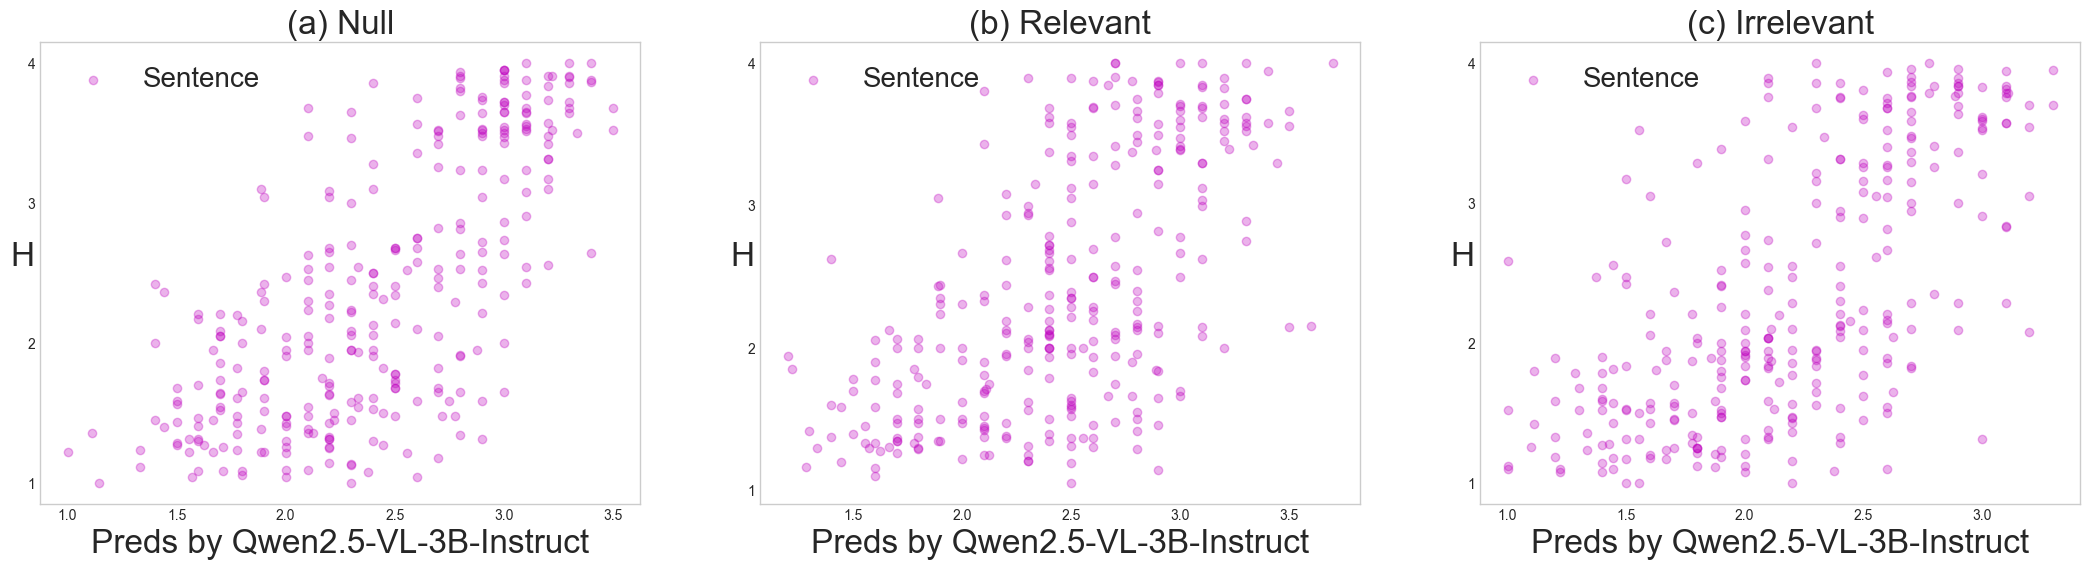

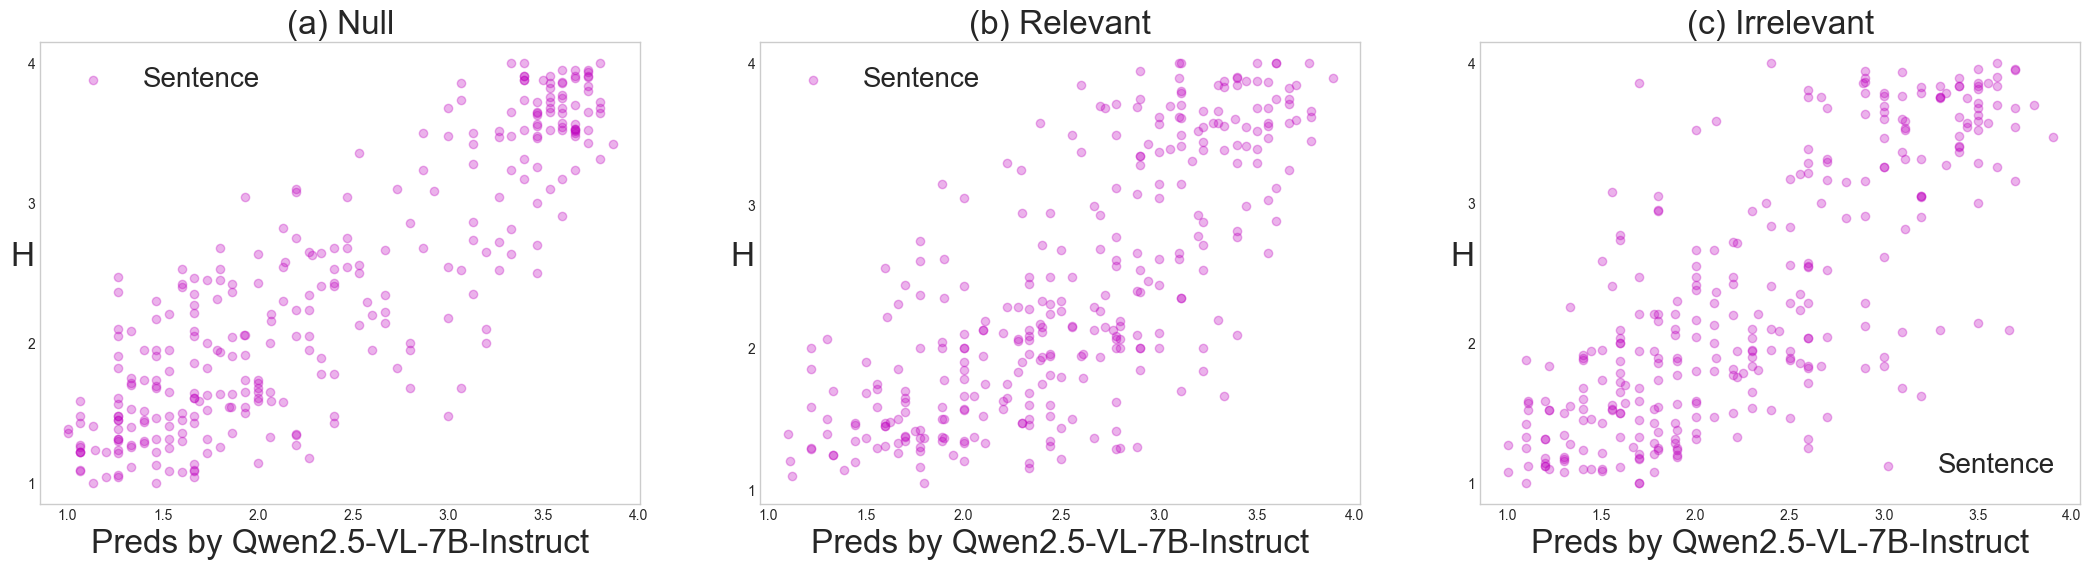

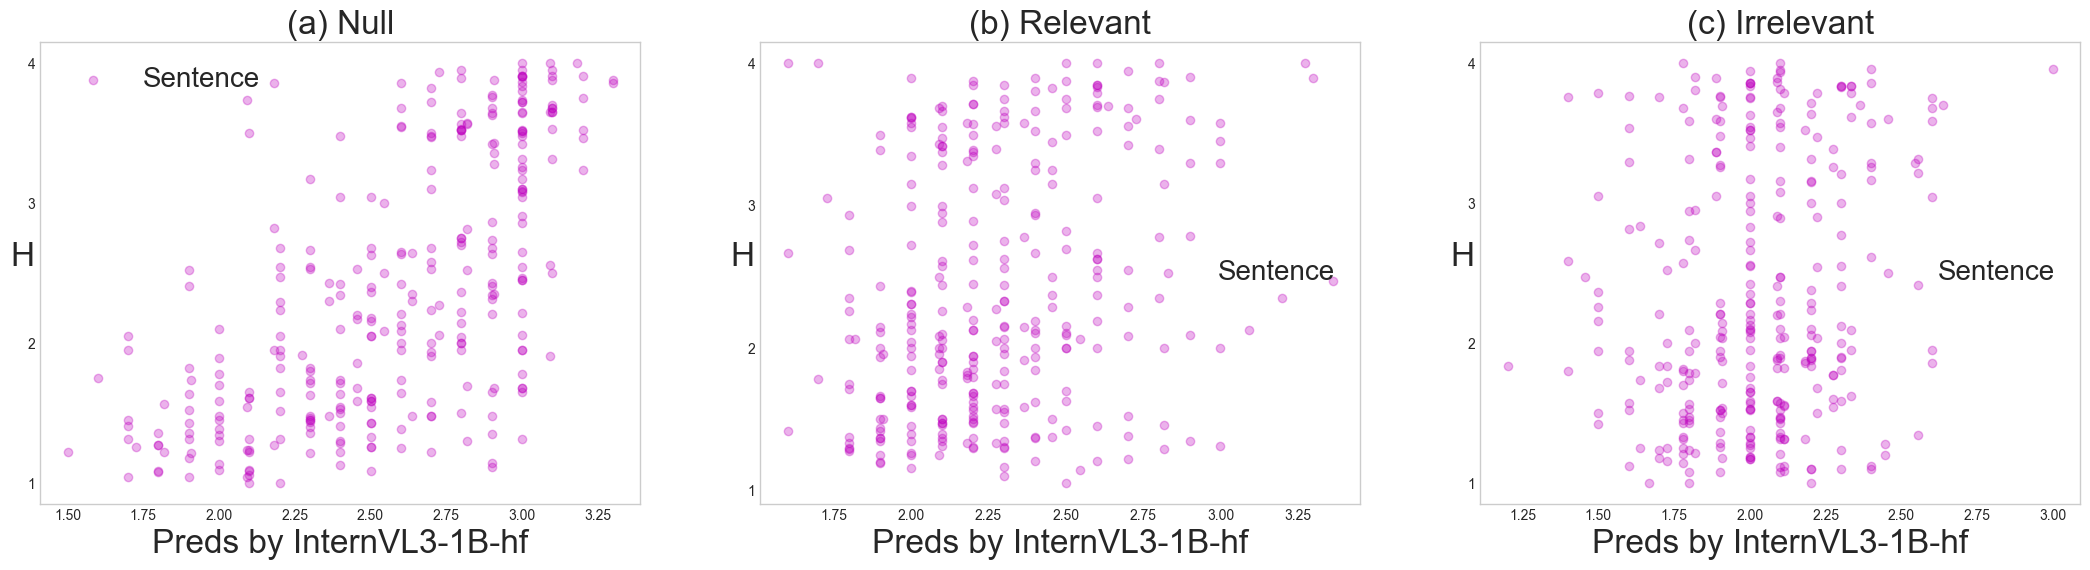

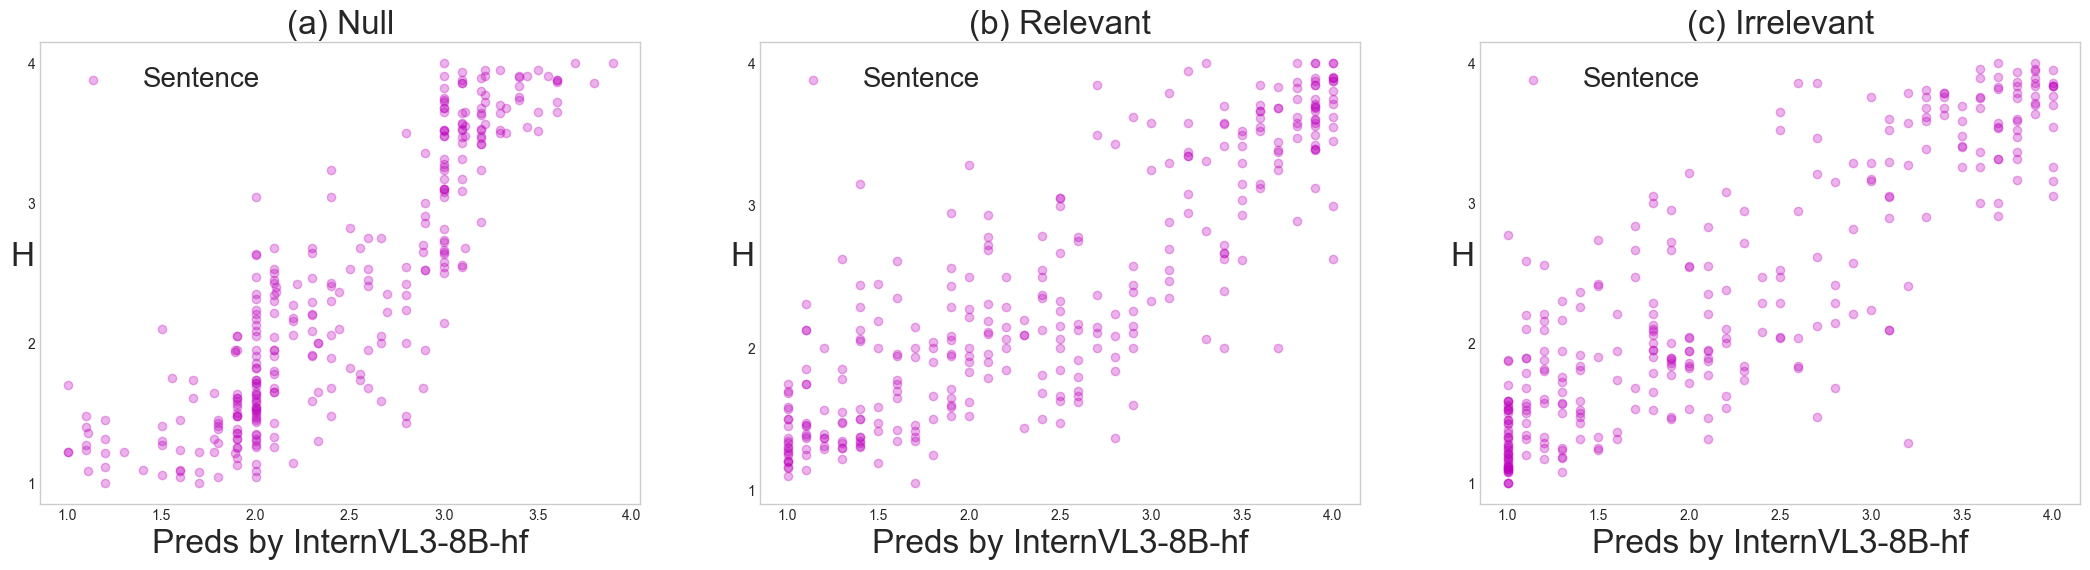

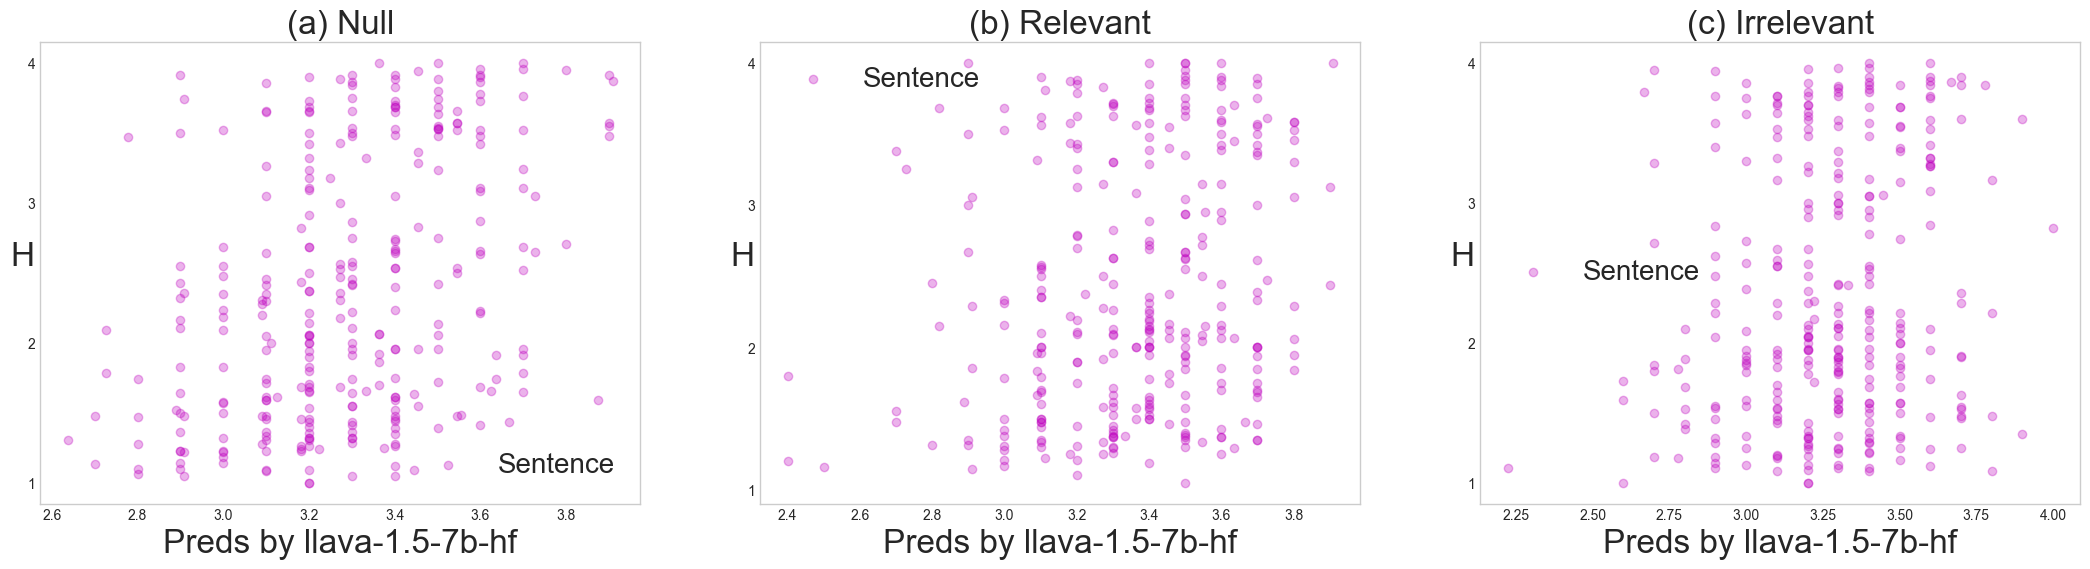

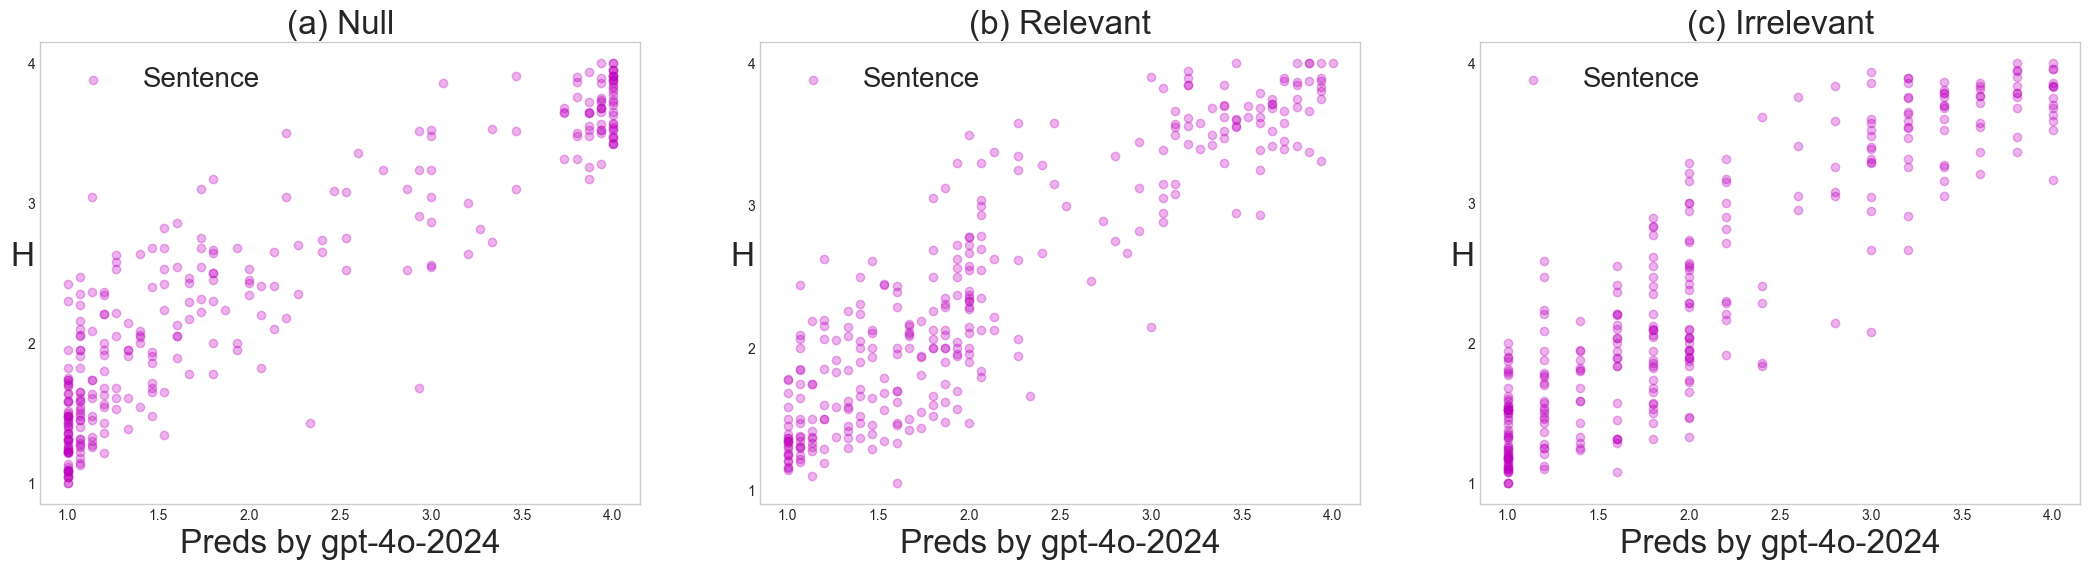

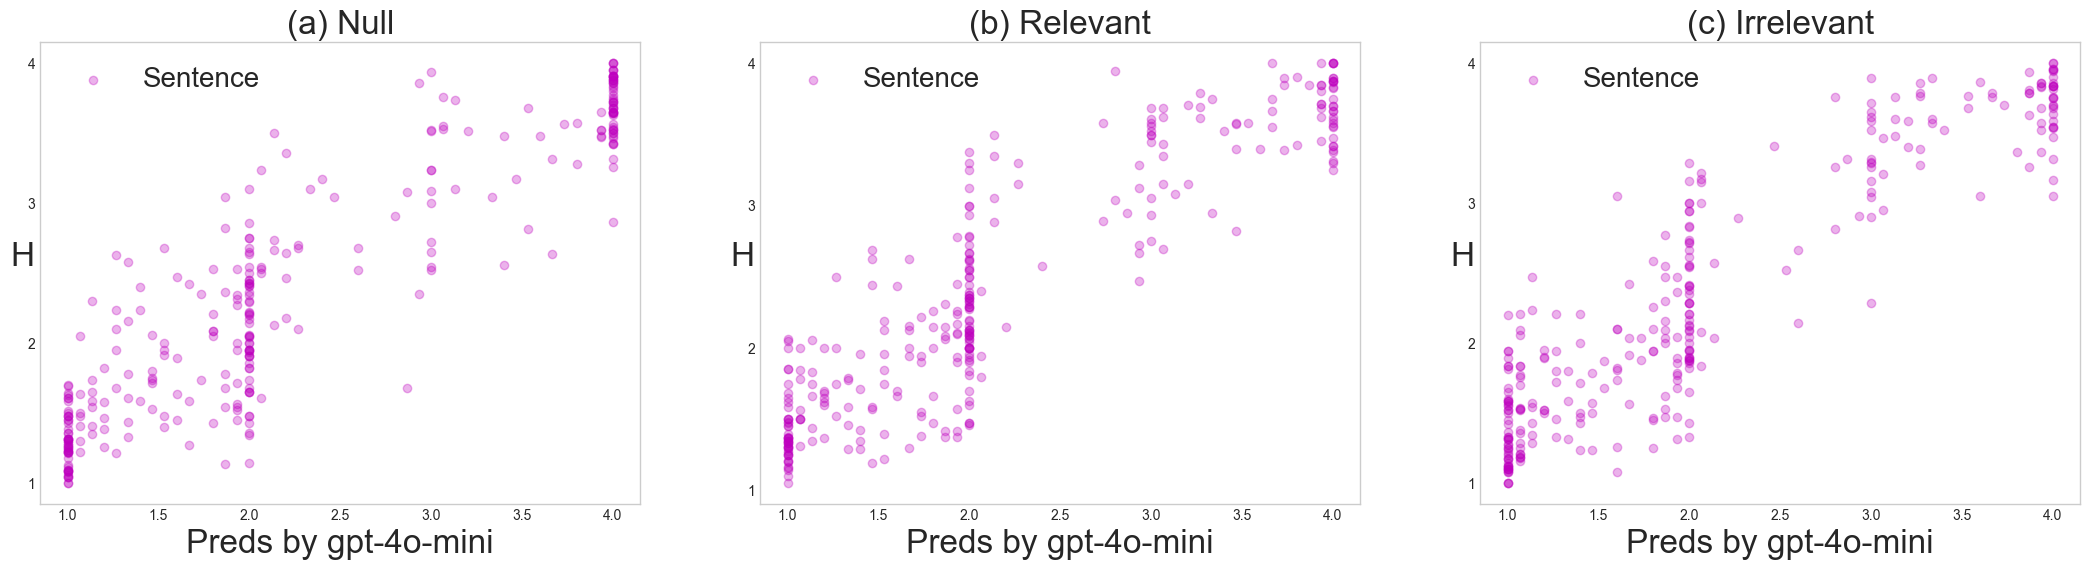

In [9]:
models = ["Qwen2.5-VL-3B-Instruct", 
          "Qwen2.5-VL-7B-Instruct", 
          "InternVL3-1B-hf", 
          "InternVL3-8B-hf", 
          "llava-1.5-7b-hf",
          "gpt-4o-2024",
          "gpt-4o-mini"]

model_predictions = ["./ModelPredictions/preds_Qwen2.5*3B*",
                     "./ModelPredictions/preds_Qwen2.5*7B*",
                    "./ModelPredictions/preds*InternVL3-1B-hf*",
                    "./ModelPredictions/preds*InternVL3-8B-hf*",
                    "./ModelPredictions/preds*llava*",
                    "./ModelPredictions/preds*gpt-4o-2024*",
                    "./ModelPredictions/preds*gpt-4o-mini*"]


filename_human = "sentences.csv"
avg_human = get_avg_human_ratings(filename_human)

for model, mp in zip(models, model_predictions):
    if "gpt" in model:
        avg_model = get_avg_model_ratings(mp, model, open_source=False)
    else:
        avg_model = get_avg_model_ratings(mp, model, open_source=True)

    x_name = "Preds by " + model 
    y_name = "H"
    score_method = "preds"
    plot_data(avg_model, avg_human, model, x_name, y_name)

#### Plot 2: human ratings ~ model (internal) scores

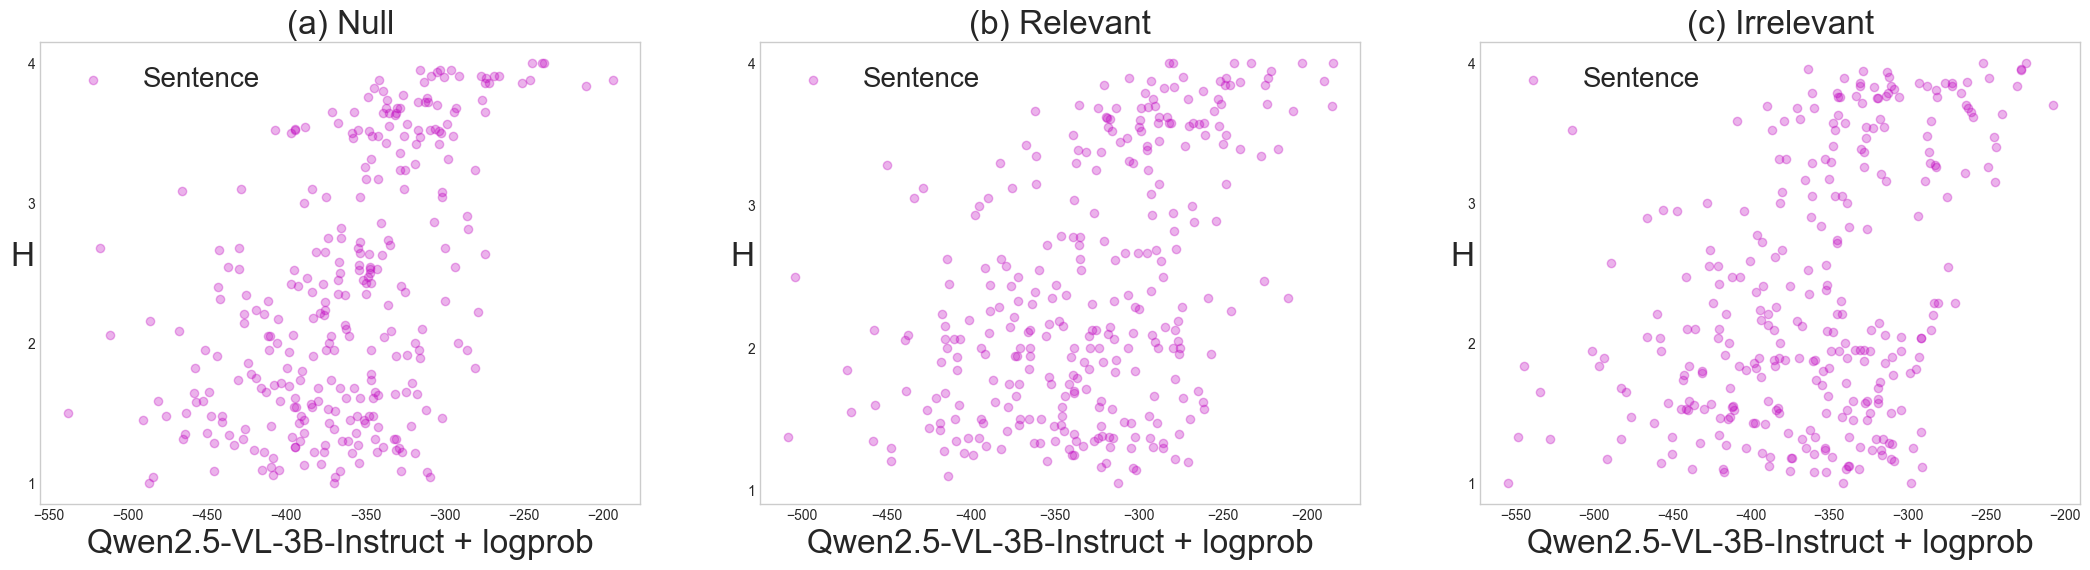

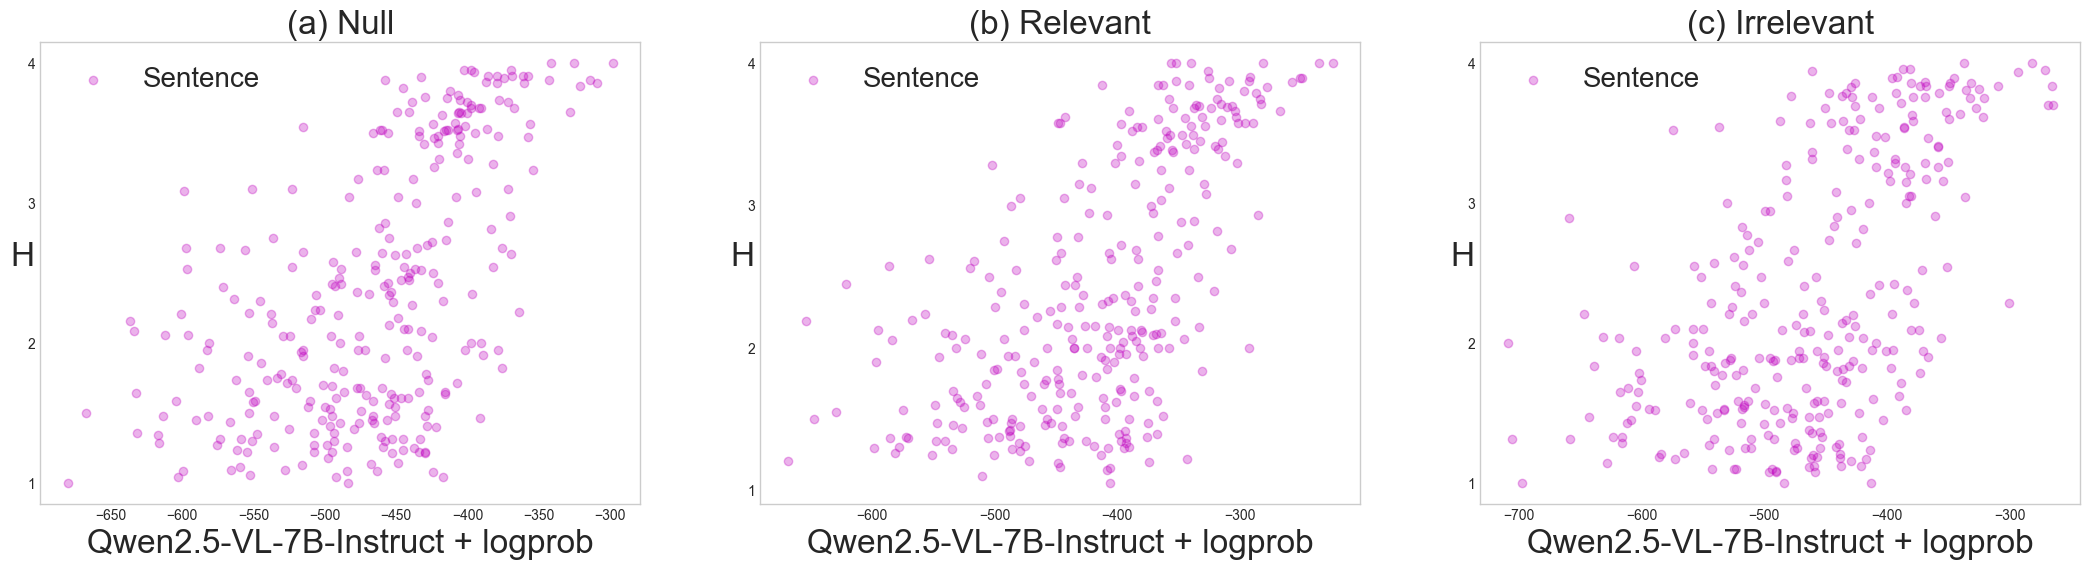

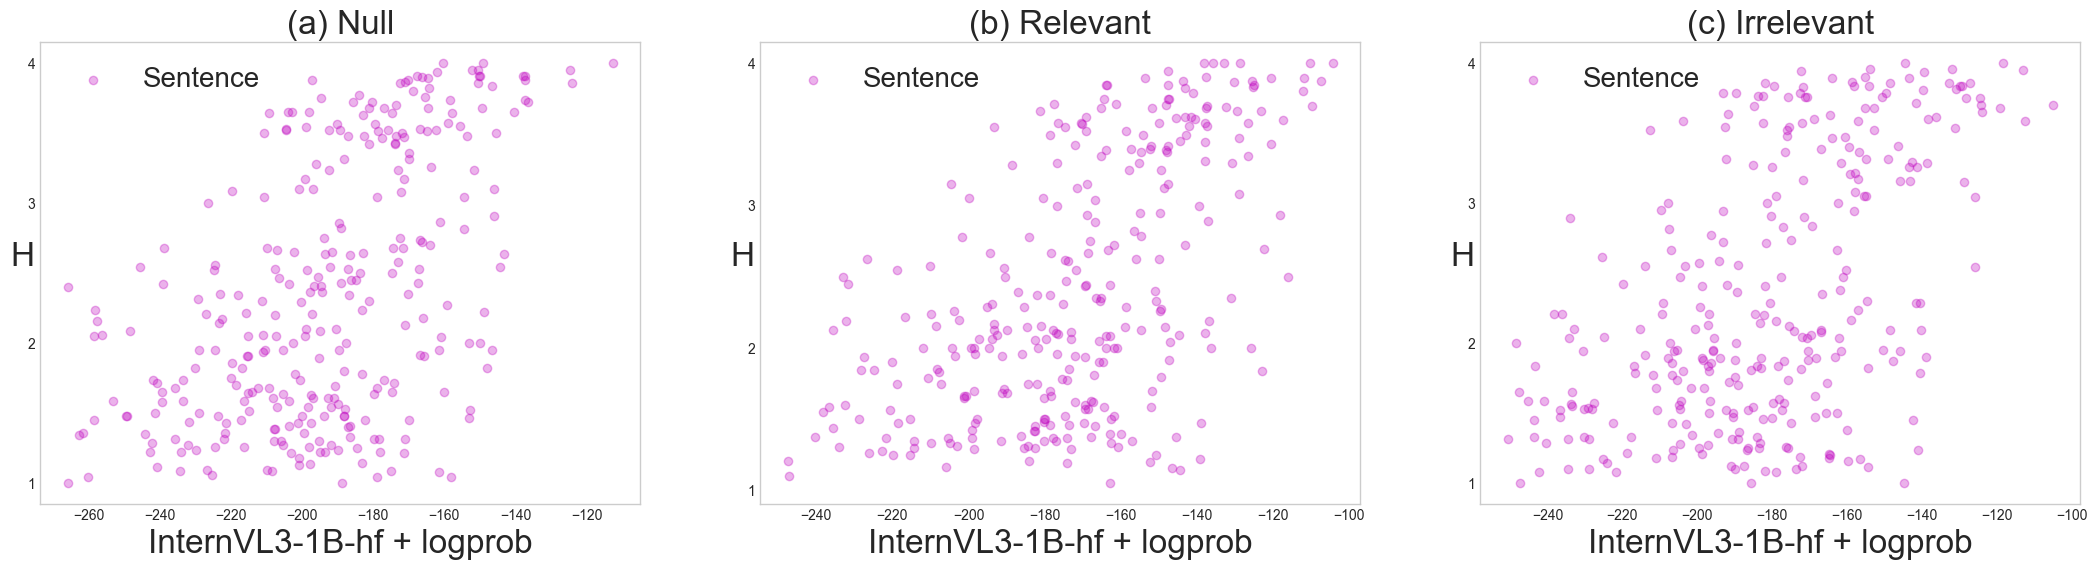

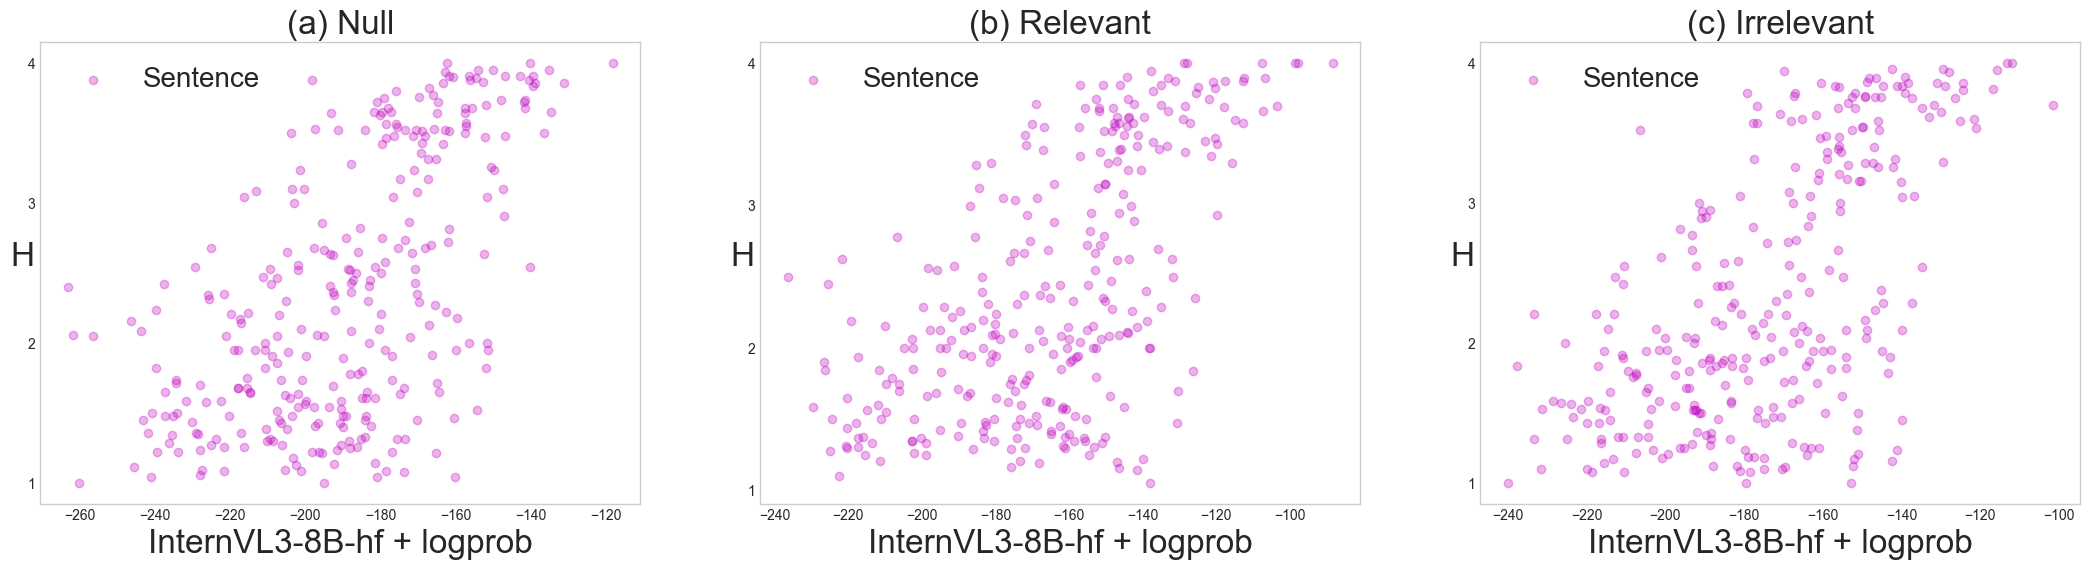

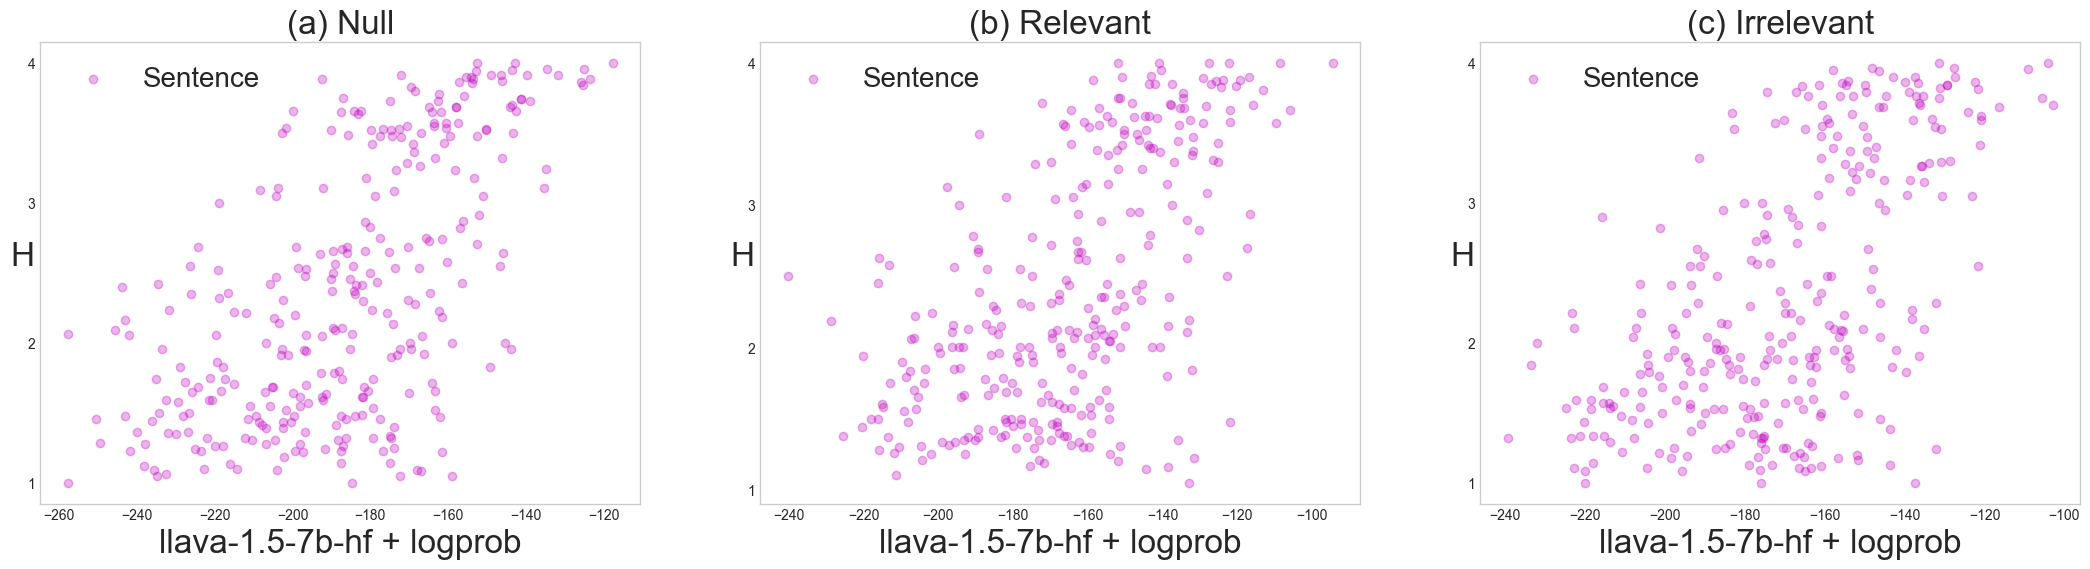

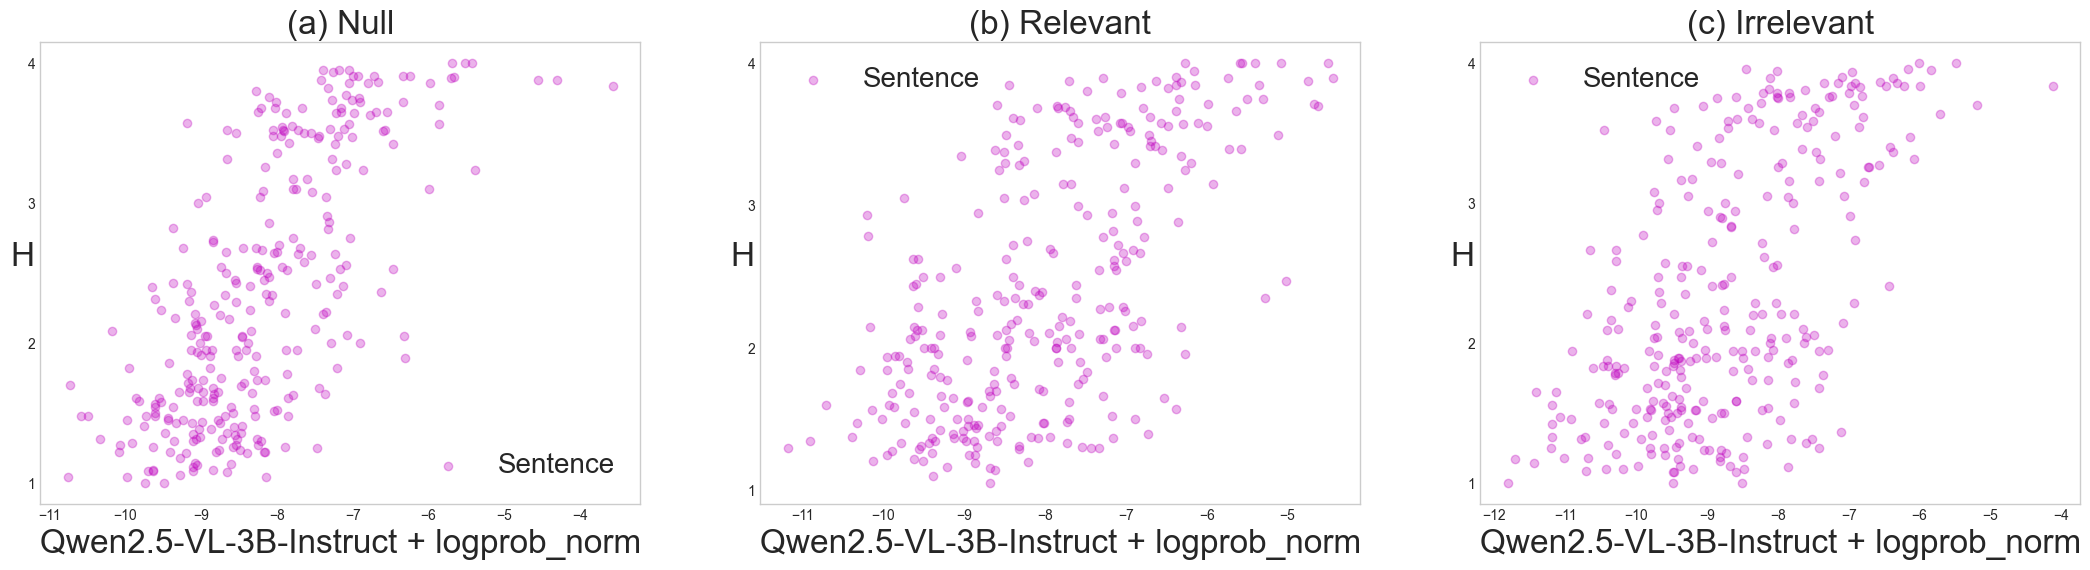

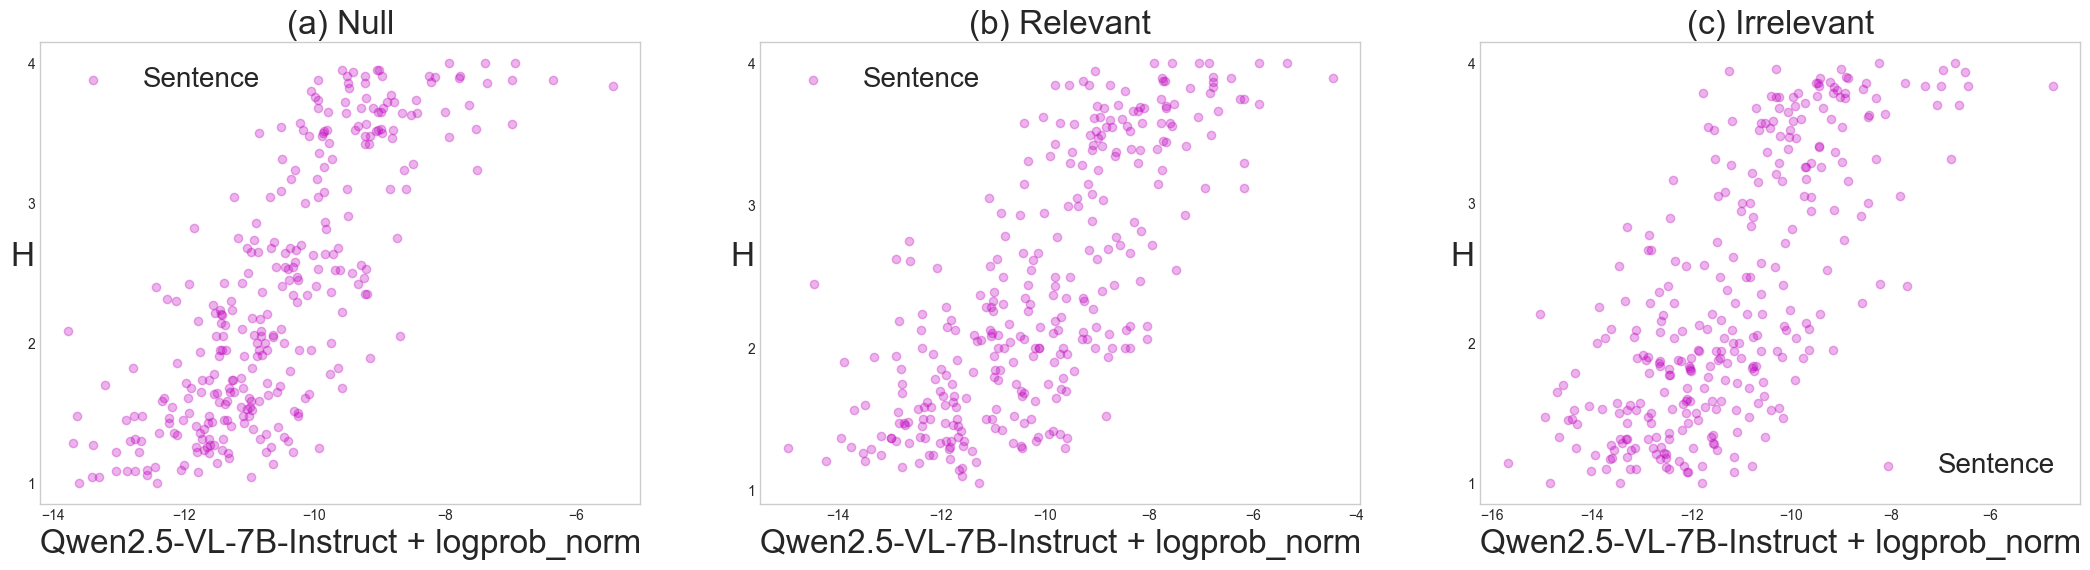

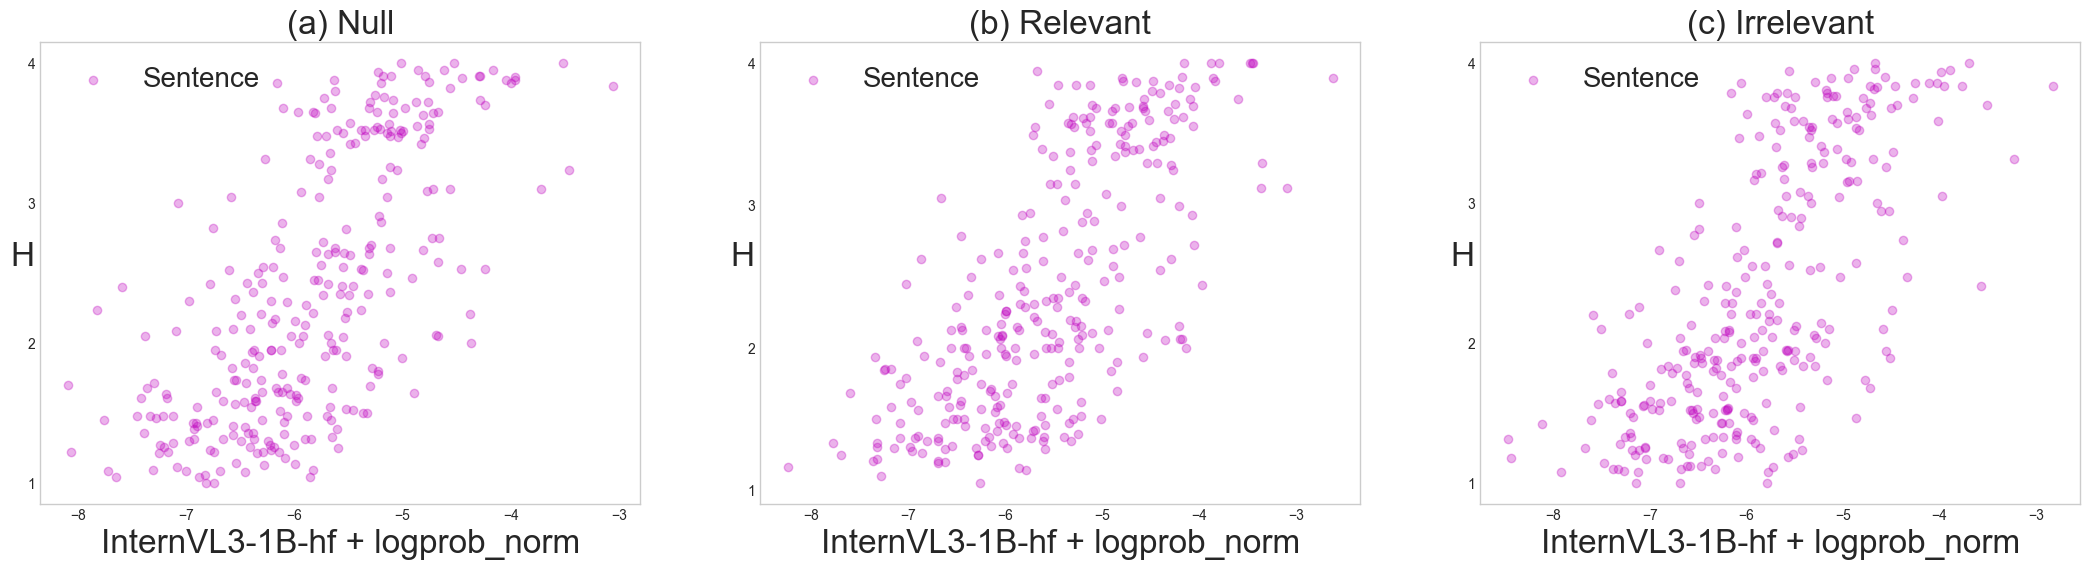

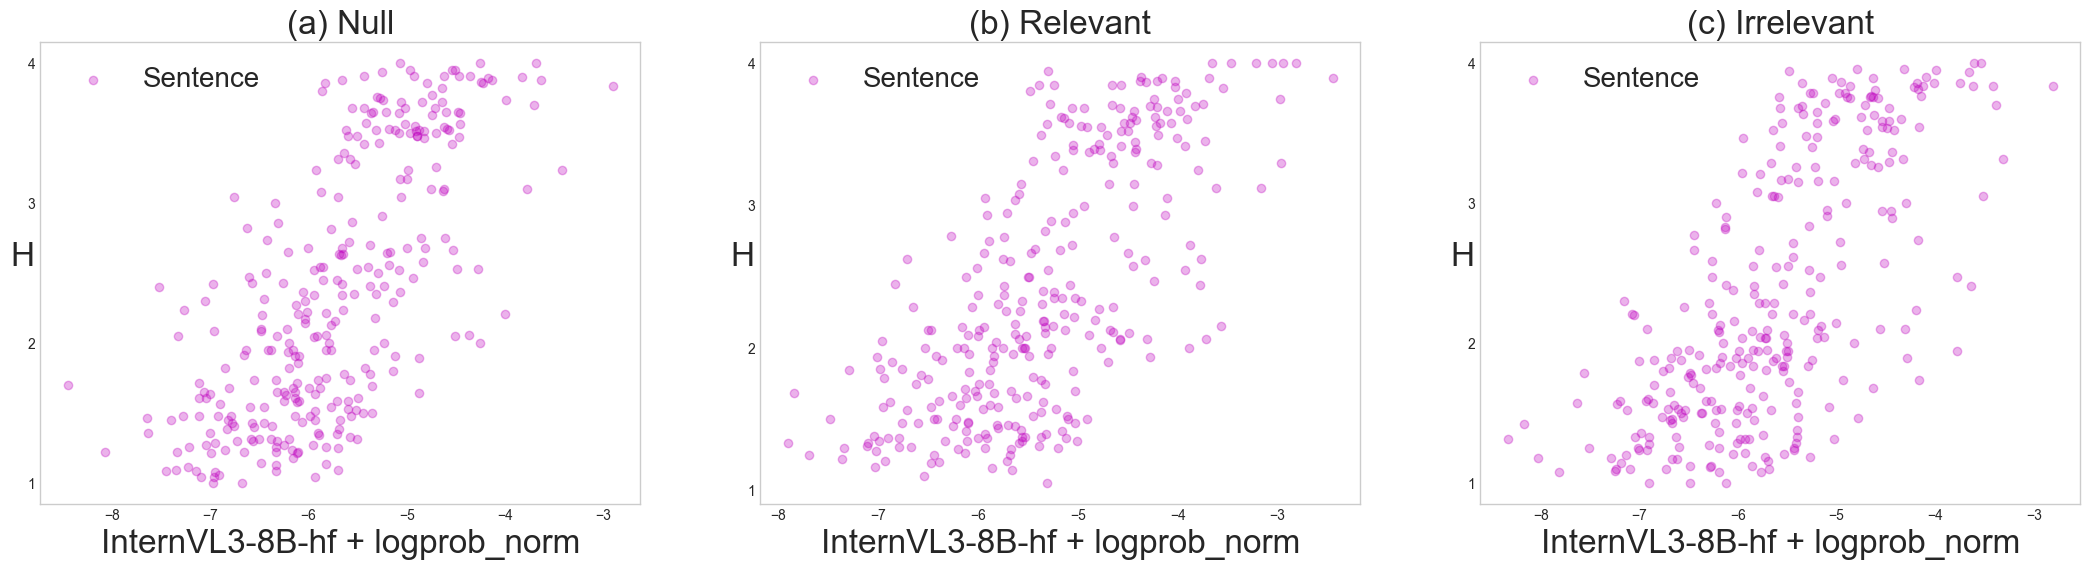

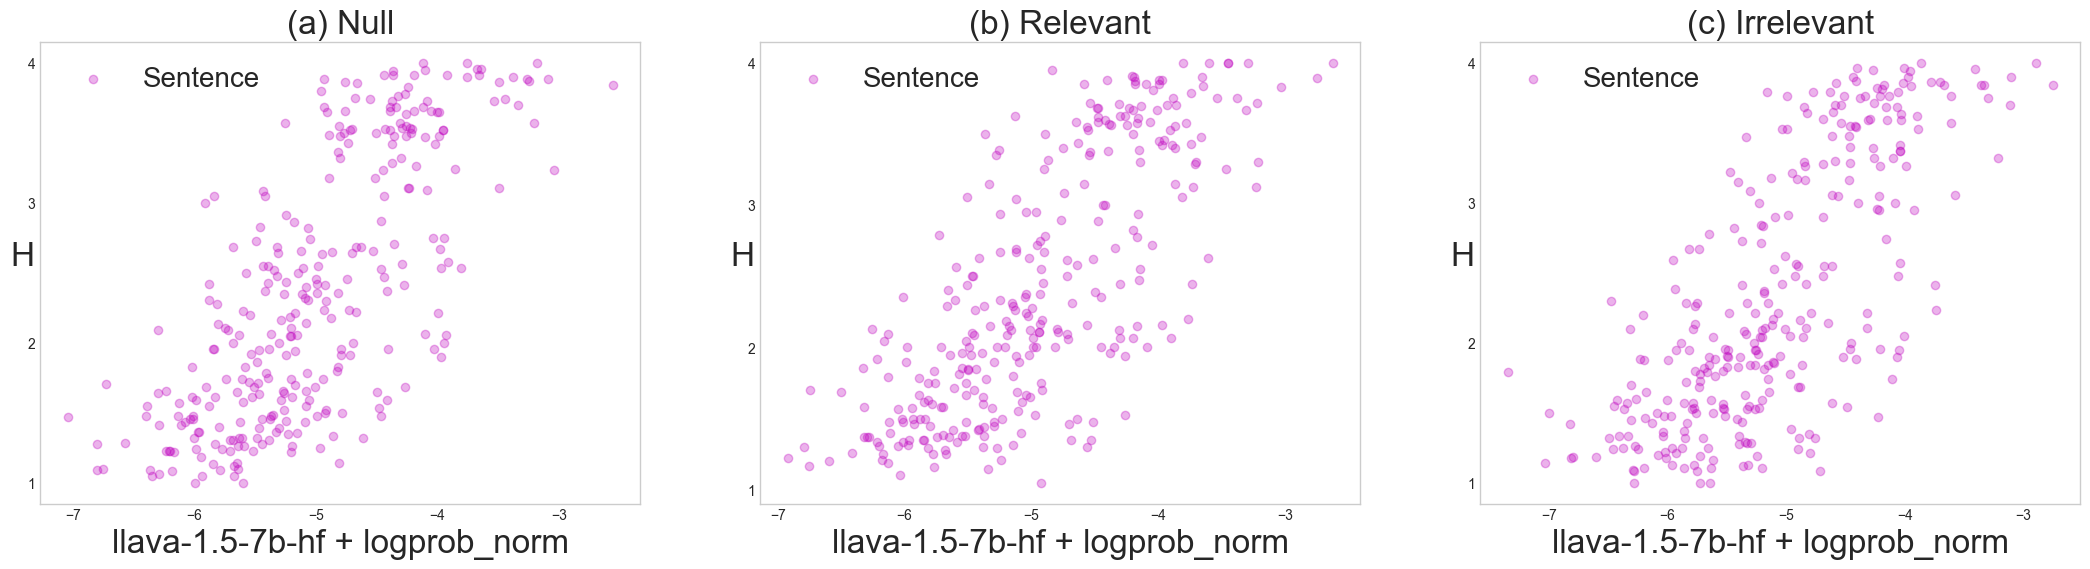

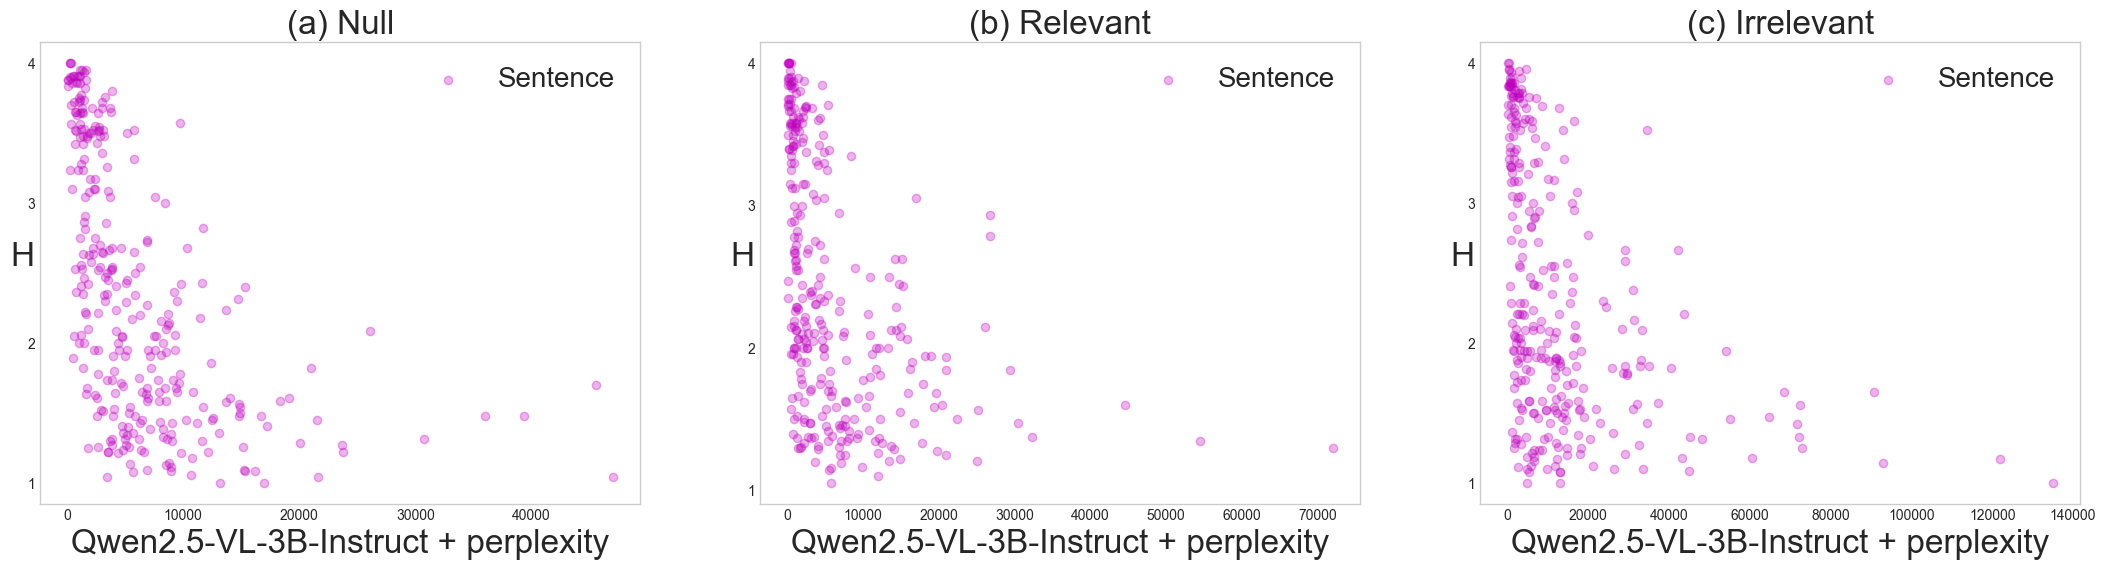

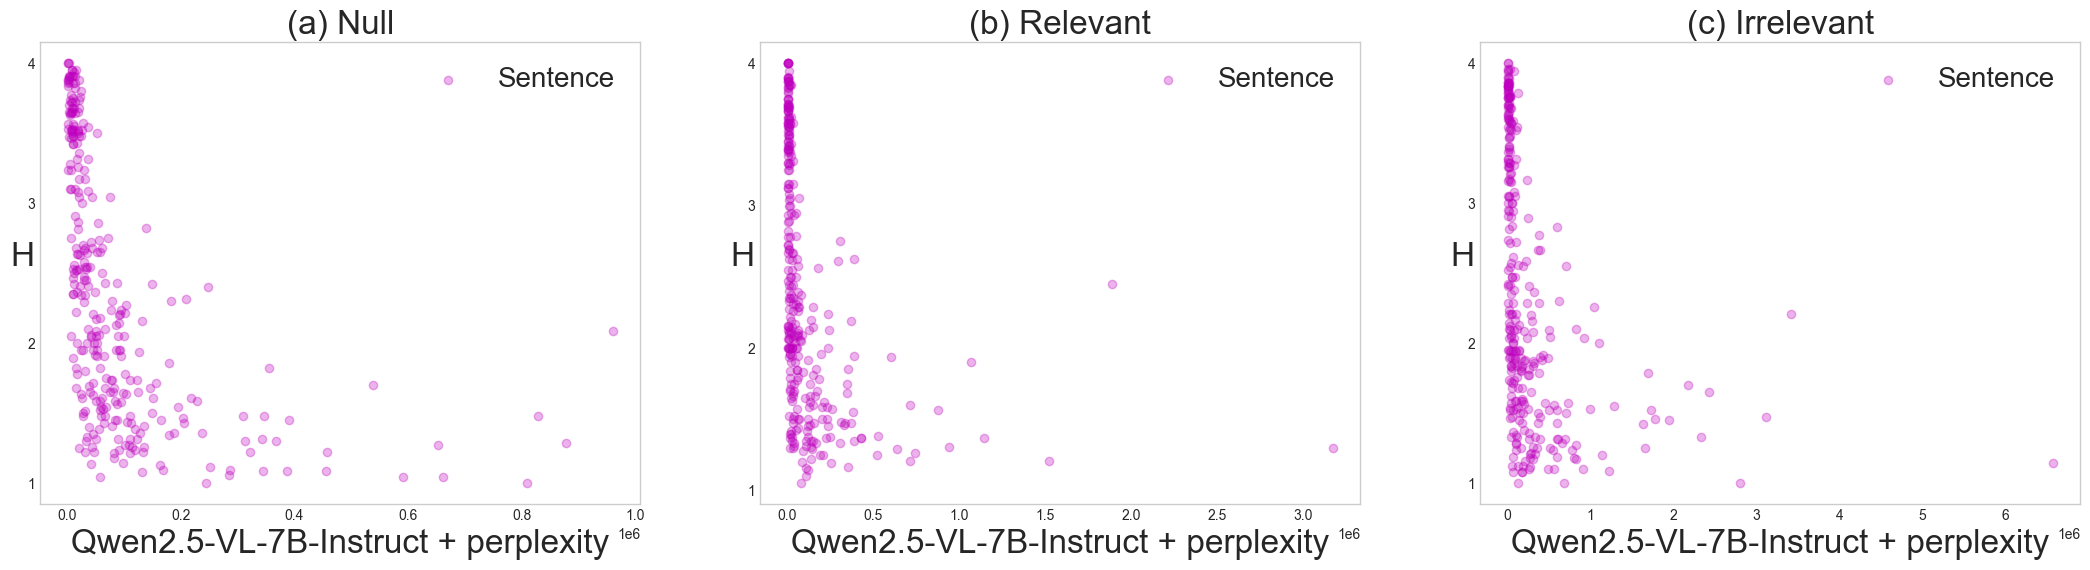

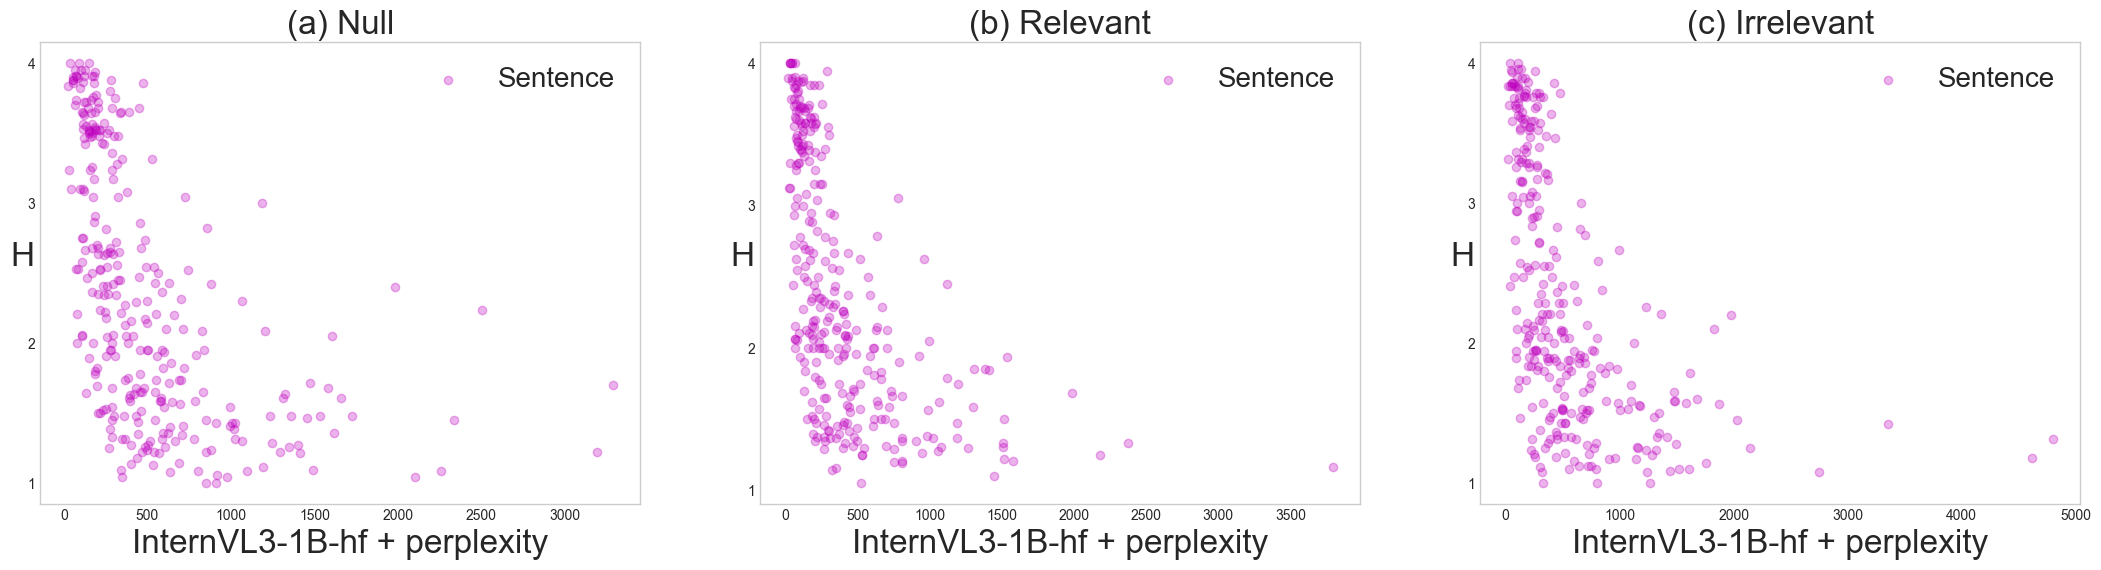

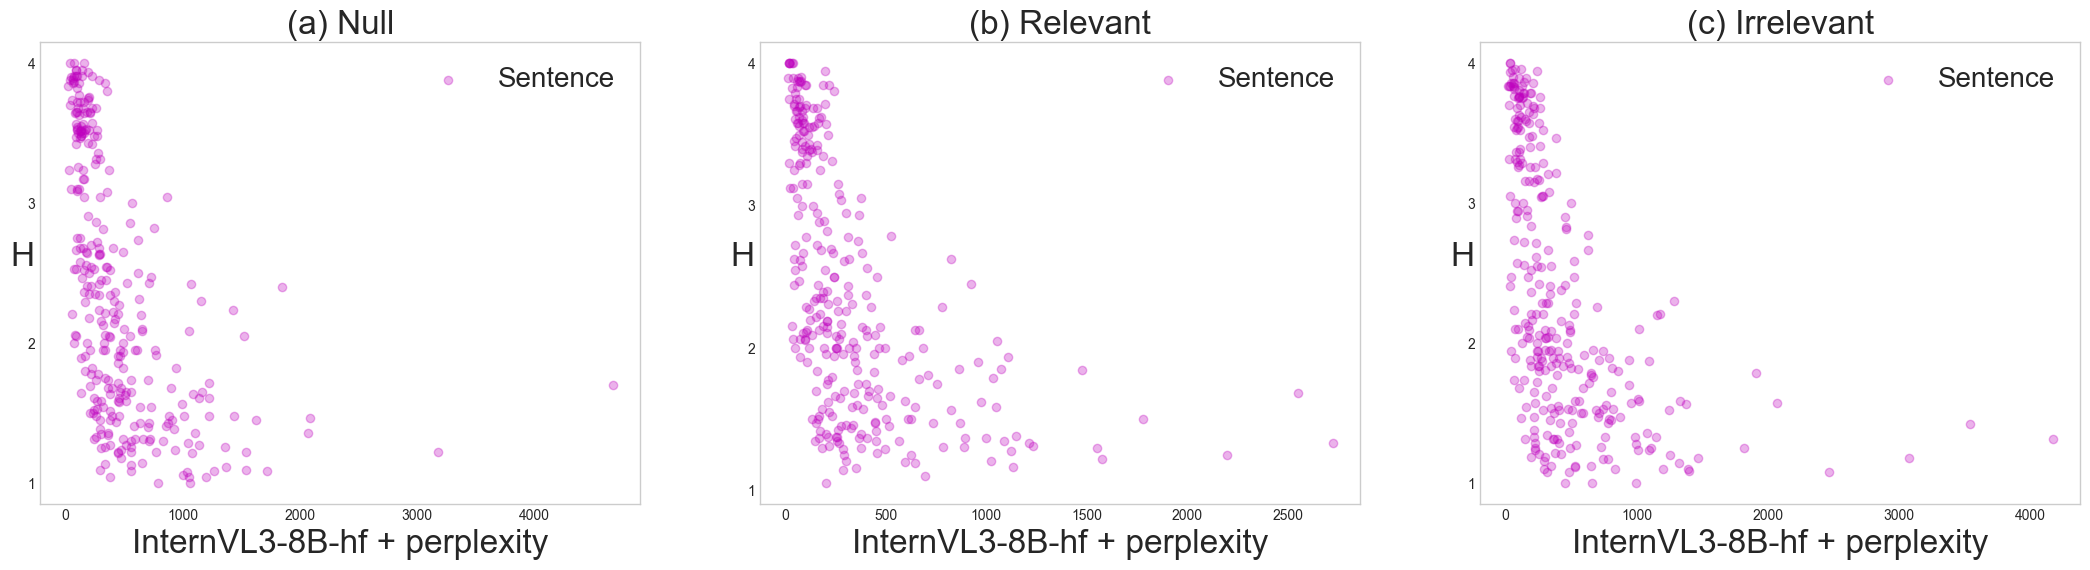

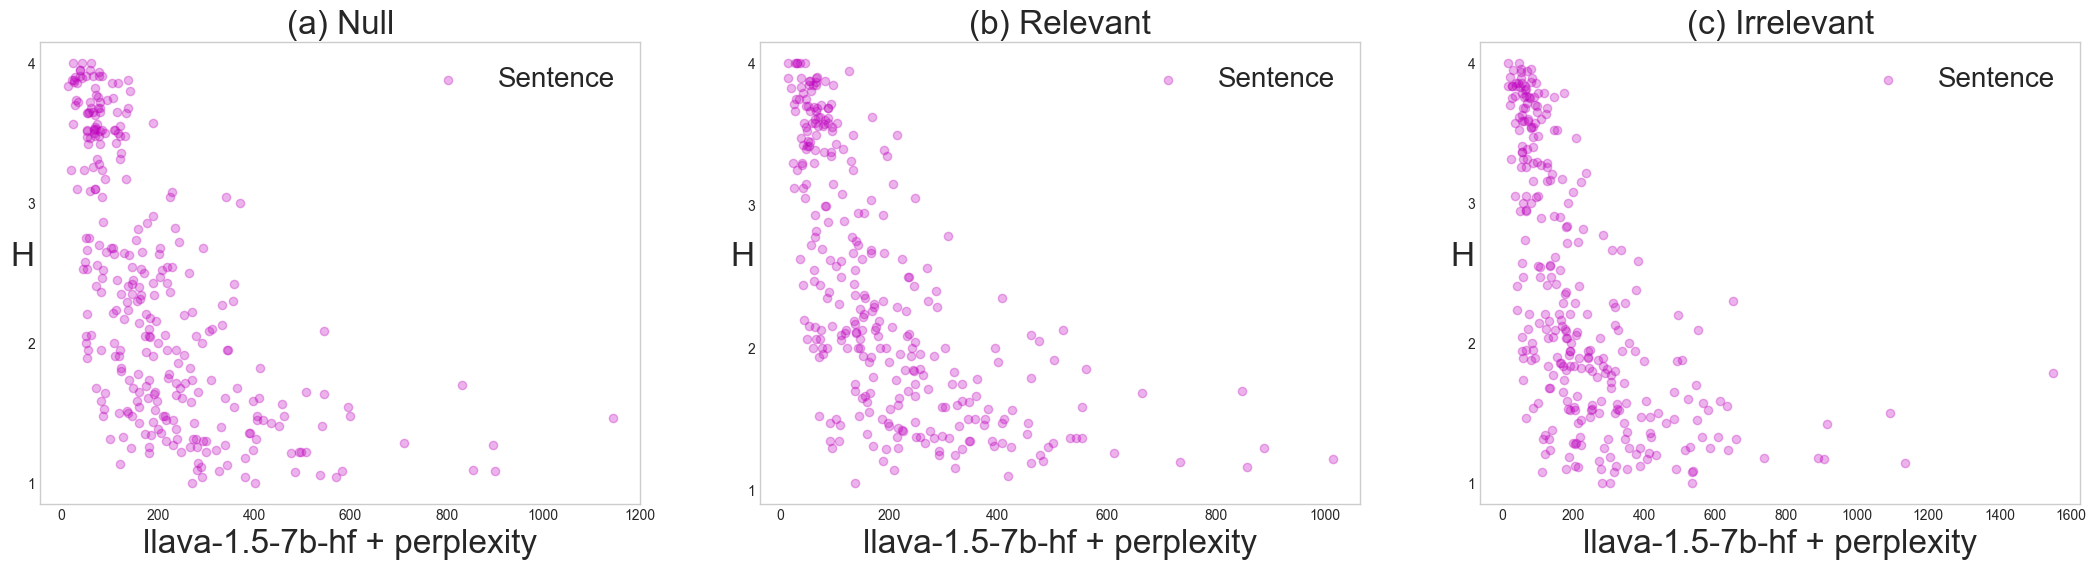

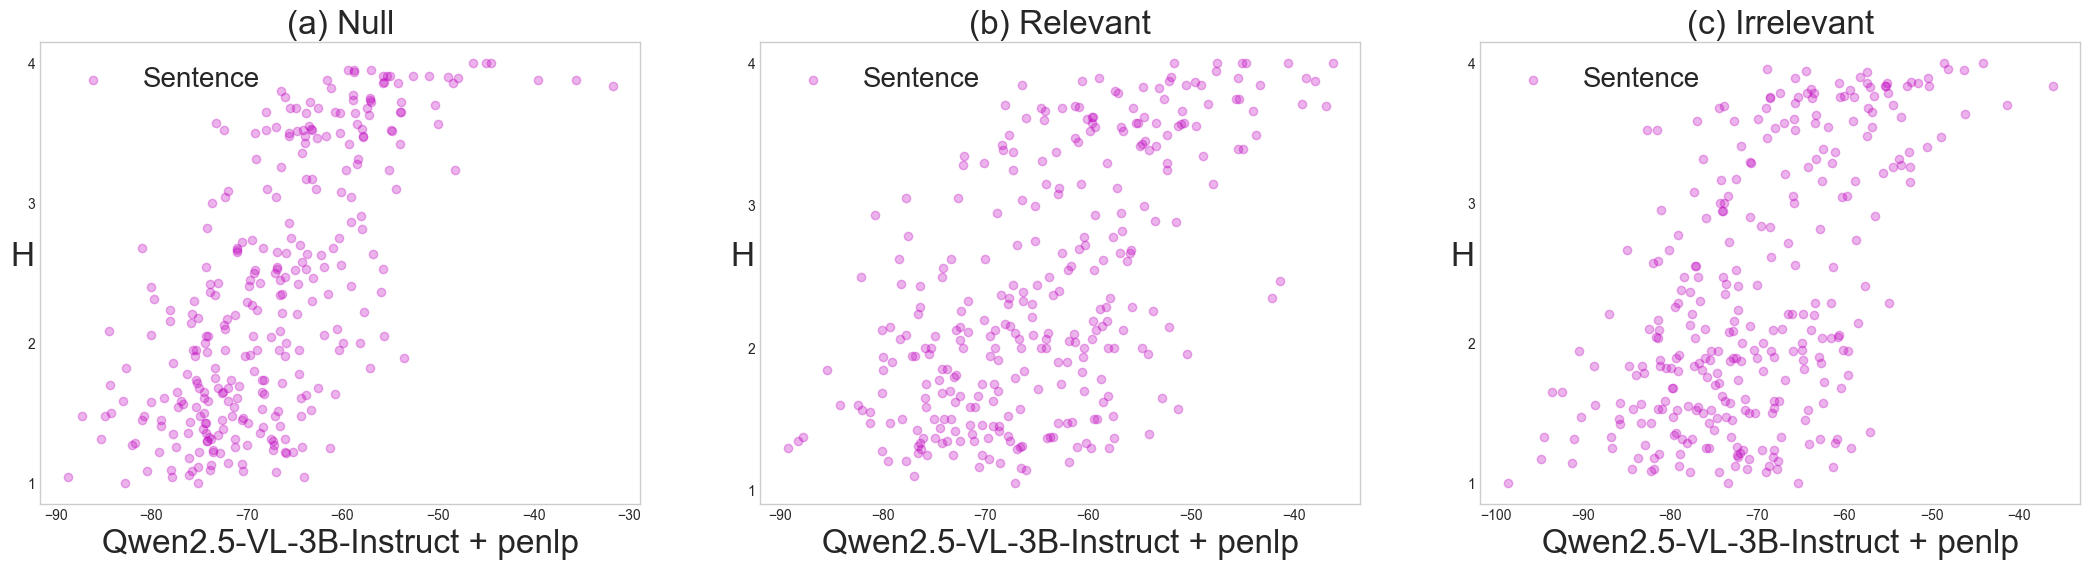

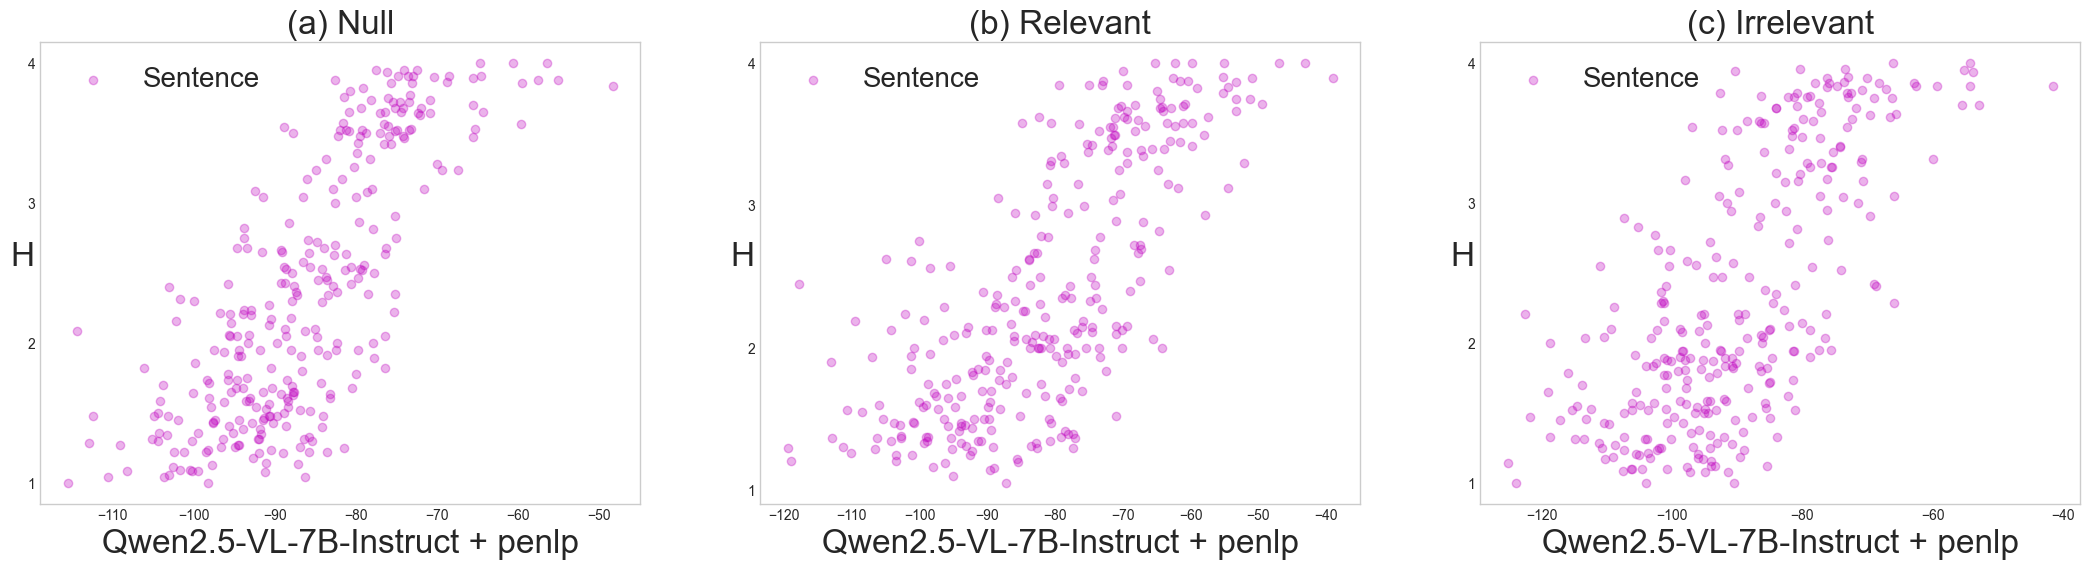

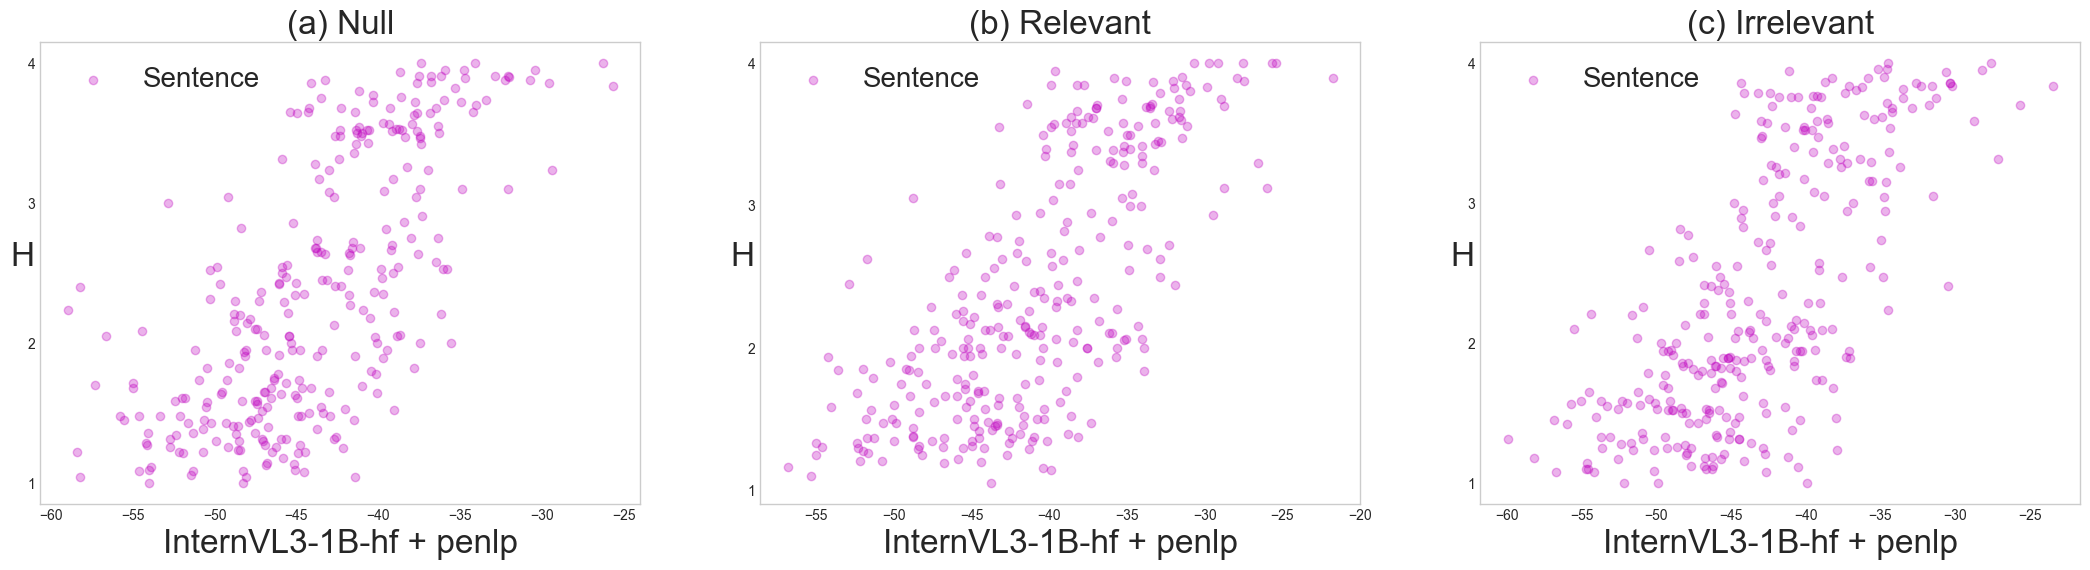

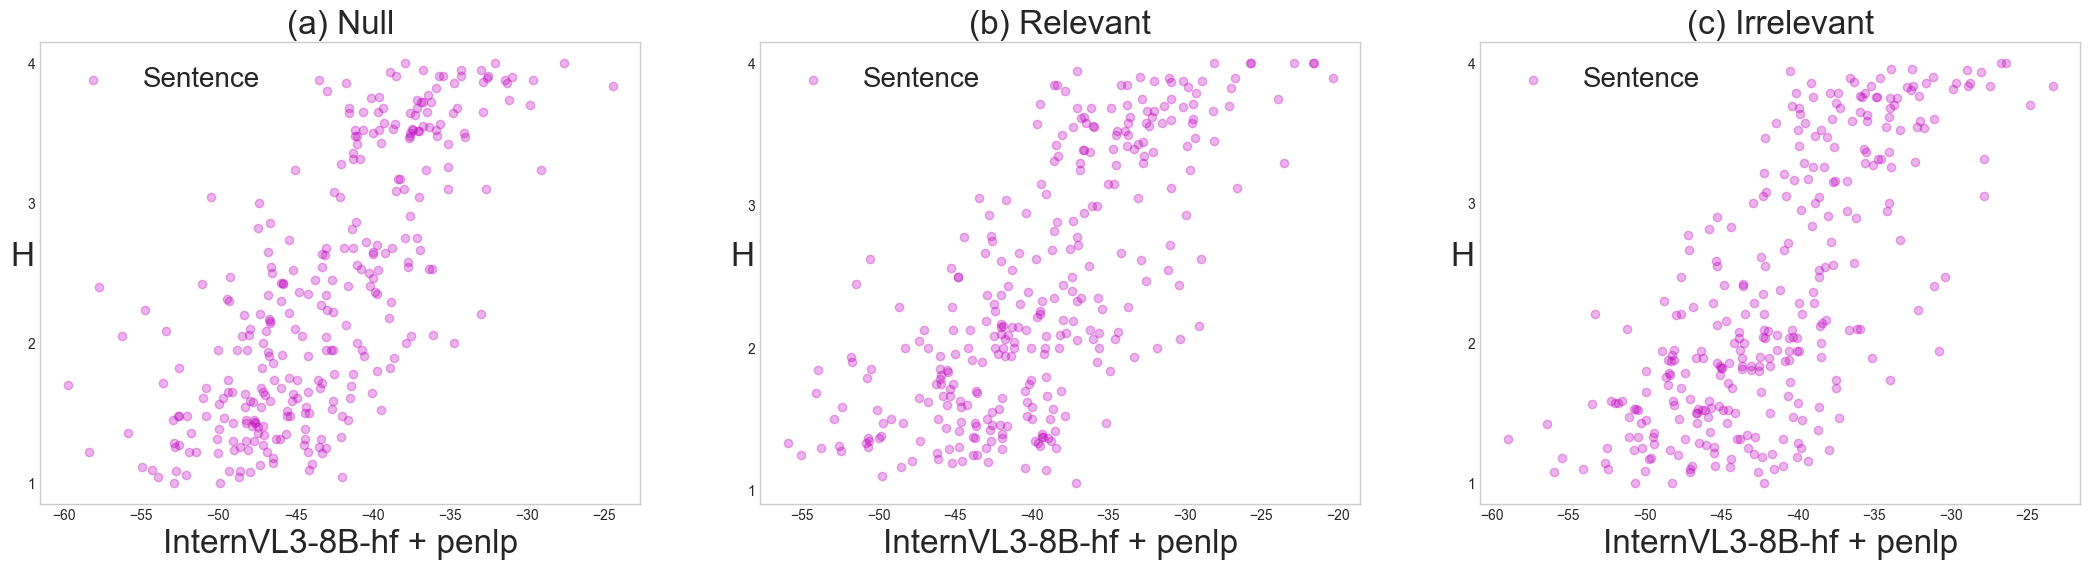

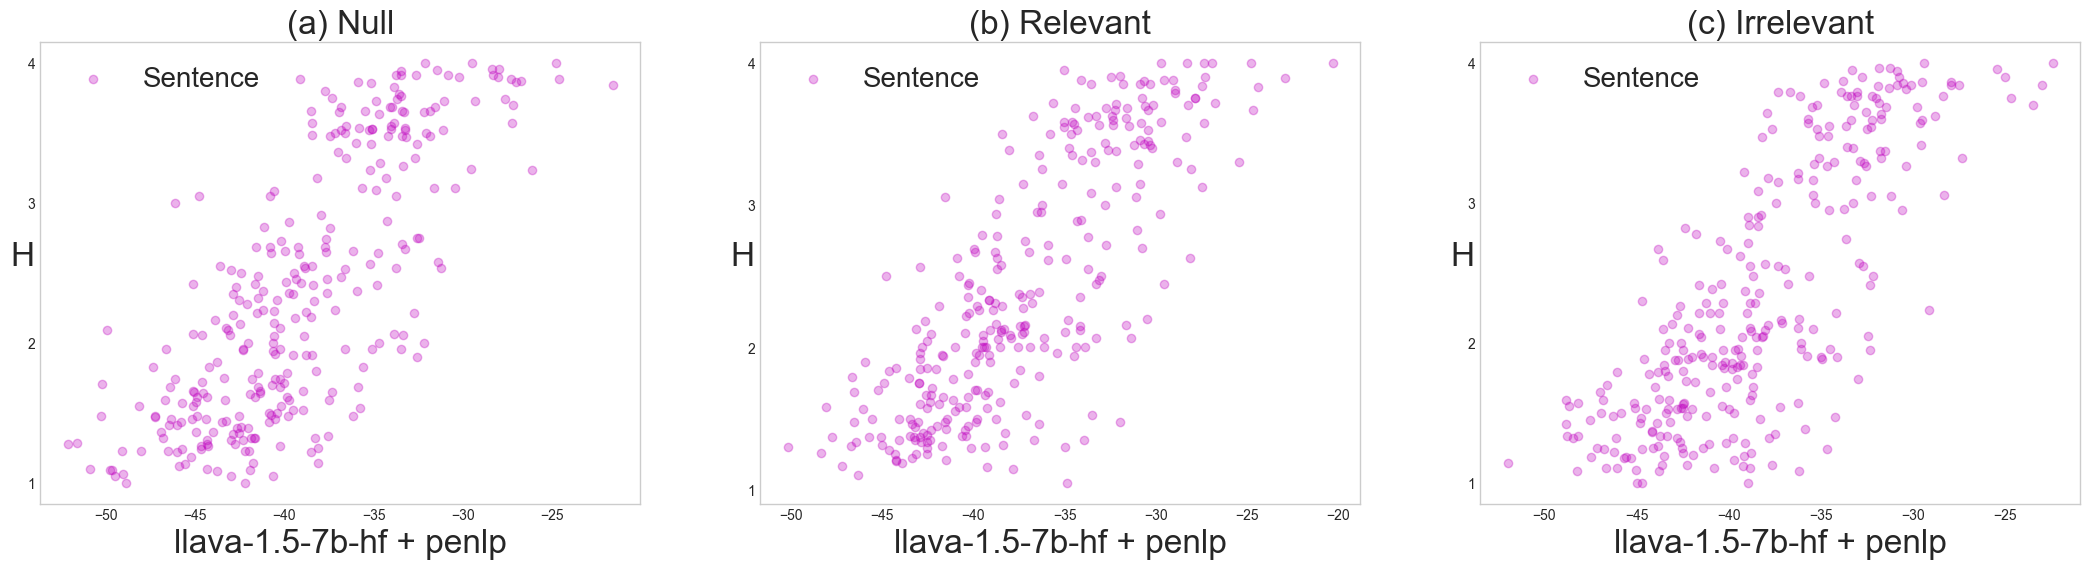

In [10]:
models = ["Qwen2.5-VL-3B-Instruct", 
          "Qwen2.5-VL-7B-Instruct", 
          "InternVL3-1B-hf", 
          "InternVL3-8B-hf", 
          "llava-1.5-7b-hf"]

filename_human = "sentences.csv"
avg_human = get_avg_human_ratings(filename_human)

logit_path = "ModelLogits/scores*"

corr_df_all = []
for score_method in ["logprob", "logprob_norm", "perplexity", "penlp"]:
    avg_model = get_avg_model_scores(load_score_data(logit_path), score_method)
    for model in models:
        x_name = model + " + " + score_method
        y_name = "H"
        plot_data(avg_model, avg_human, model, x_name, y_name)